In [1]:
import os 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from statsmodels.tsa.api import ARDL
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.gofplots import qqplot
import joblib
import sys
sys.path.append(os.path.abspath('..'))
from src.analytics.MonteCarloSimulation import MonteCarlo
import plotly.graph_objects as go
from scipy.interpolate import griddata


import warnings
warnings.filterwarnings('ignore')


In [2]:
data_path = os.path.join("..", "data", 'processed', 'dados_modelagem.csv')
df = pd.read_csv(data_path)
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df = df.set_index('data')

# Definiçao da Volatidade

In [3]:
# desvio padrao do retorno-log dado lag 
ret = np.log(df['Close_PETR4.SA'] / df['Close_PETR4.SA'].shift(1))
df['sigma'] = ret.rolling(3).std()

<Axes: title={'center': 'volatidade - Close_PETR4.SA'}, xlabel='data'>

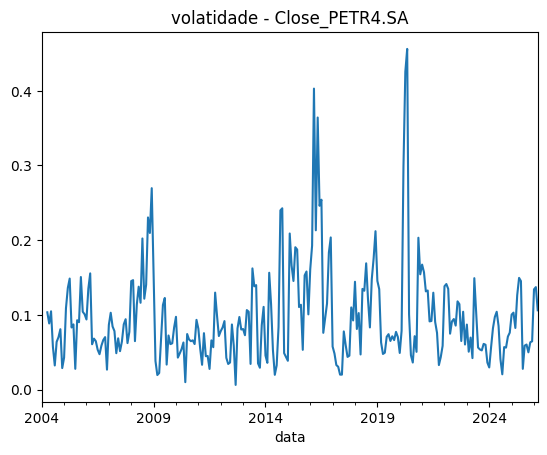

In [4]:
plt.title("volatidade - Close_PETR4.SA")
df['sigma'].plot()

In [5]:
# excluindo os preços para evitar vazamento
df = df.drop('Close_PETR4.SA', axis=1)
df = df.dropna()

In [6]:
df_train = df.loc['2004-01-01':'2024-06-01'] # inicio de 2004 ate o primeiro semestre de 2021 
df_test = df.loc['2024-07-01':'2026-03-01'] # ate março de 2026 

In [7]:
print("dimensoes dos dados")
print("==="*50)
print()
print(f"Dados de treino: linhas -> {df_train.shape[0]} | colunas -> {df_train.shape[1]} | inicio: {df_train.reset_index()['data'].min()} -> final:{df_train.reset_index()['data'].max()}")
print()
print(f"Dados de teste: linhas -> {df_test.shape[0]} | colunas -> {df_test.shape[1]} | inicio: {df_test.reset_index()['data'].min()} -> final:{df_test.reset_index()['data'].max()}")
print()
print("==="*50)

dimensoes dos dados

Dados de treino: linhas -> 243 | colunas -> 14 | inicio: 2004-04-01 00:00:00 -> final:2024-06-01 00:00:00

Dados de teste: linhas -> 21 | colunas -> 14 | inicio: 2024-07-01 00:00:00 -> final:2026-03-01 00:00:00



In [8]:
models = {
    "Arvore_de_decisao": DecisionTreeRegressor(random_state=42), 
    "Gradient_Boosting":GradientBoostingRegressor(random_state=42), 
    "XGBoost": XGBRegressor(),
    "AdaBoost": AdaBoostRegressor(random_state=42)
    
}

In [9]:
# separaçao de x e y (treino)
X_train = df_train.drop('sigma', axis=1)
y_train = df_train['sigma']
y_train = y_train.fillna(y_train.mean())

In [10]:
# x e y (teste)
X_test = df_test.drop('sigma', axis=1)
y_test = df_test['sigma']


# VIF

In [11]:
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
8,IBC-Br,697.525491
0,Produção de derivados de petróleo,335.530963
6,Producao Industrial,246.604517
1,Consumo de derivados de petróleo - gasolina,97.193755
10,Close_IBOV,75.407442
4,Cambio - IPCA,41.898714
2,Consumo de derivados de petróleo - Óleo combus...,26.067222
3,Selic,19.943118
11,BETA,17.702215
12,regime,4.582017


# Correlaçao das variaveis com o target

In [12]:
corr = df_train.corr()['sigma']
corr

Produção de derivados de petróleo                      0.062870
Consumo de derivados de petróleo - gasolina           -0.008842
Consumo de derivados de petróleo - Óleo combustível   -0.091654
Selic                                                 -0.033779
Cambio - IPCA                                          0.206205
IPCA                                                  -0.000329
Producao Industrial                                   -0.247313
Balança comercial                                     -0.034258
IBC-Br                                                -0.064072
Volume_PETR4.SA                                        0.082541
Close_IBOV                                            -0.040097
BETA                                                   0.367801
regime                                                 0.345007
sigma                                                  1.000000
Name: sigma, dtype: float64

# Teste de Estacionaridade 

In [13]:
for i in X_train.columns:
    p_value = adfuller(X_train[i], autolag='AIC', maxlag=3)[1]
    print(f"{i} -> p_valor: {p_value}")
    if p_value > 0.05:
        print("hipotese nula aceita -> a serie nao é estacionaria")
    else: 
        print("hipotese nula rejeitada -> a serie é estacionaria")
    print()

Produção de derivados de petróleo -> p_valor: 0.9080329997789207
hipotese nula aceita -> a serie nao é estacionaria

Consumo de derivados de petróleo - gasolina -> p_valor: 0.367900072720754
hipotese nula aceita -> a serie nao é estacionaria

Consumo de derivados de petróleo - Óleo combustível -> p_valor: 0.08711038262226295
hipotese nula aceita -> a serie nao é estacionaria

Selic -> p_valor: 0.2564033866304989
hipotese nula aceita -> a serie nao é estacionaria

Cambio - IPCA -> p_valor: 0.24436510954401042
hipotese nula aceita -> a serie nao é estacionaria

IPCA -> p_valor: 2.9390508190897297e-12
hipotese nula rejeitada -> a serie é estacionaria

Producao Industrial -> p_valor: 7.532983723021777e-07
hipotese nula rejeitada -> a serie é estacionaria

Balança comercial -> p_valor: 5.200058758048272e-05
hipotese nula rejeitada -> a serie é estacionaria

IBC-Br -> p_valor: 0.3140389592857547
hipotese nula aceita -> a serie nao é estacionaria

Volume_PETR4.SA -> p_valor: 1.914073449592032

# Plotando grafico de autocorrelaçao 

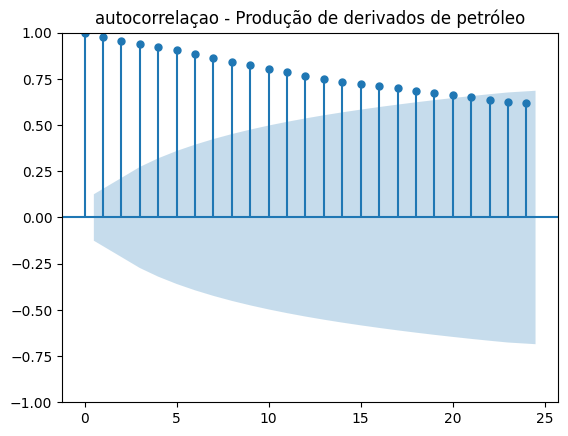

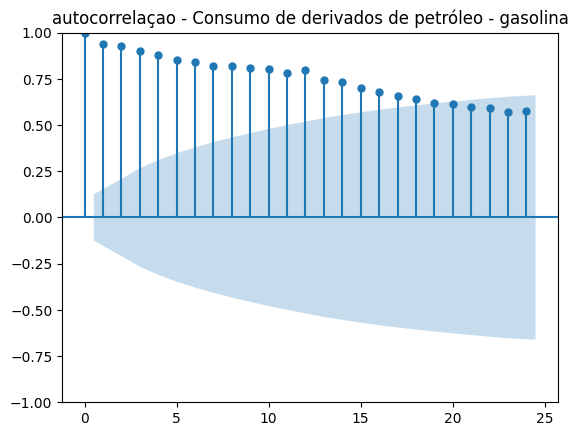

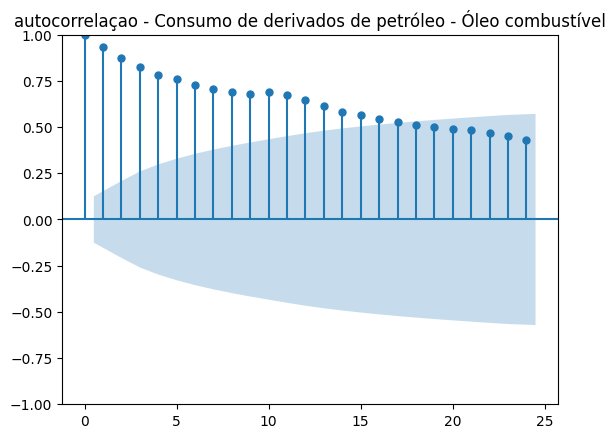

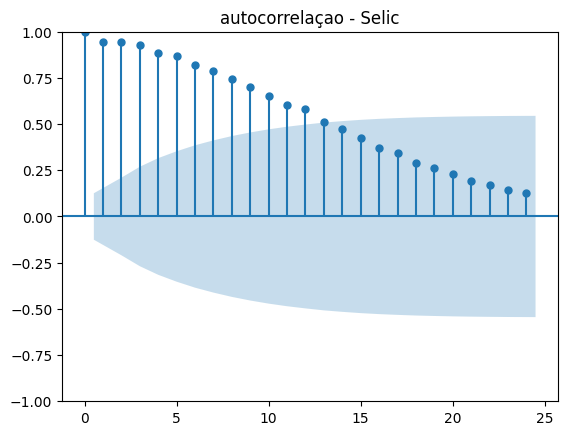

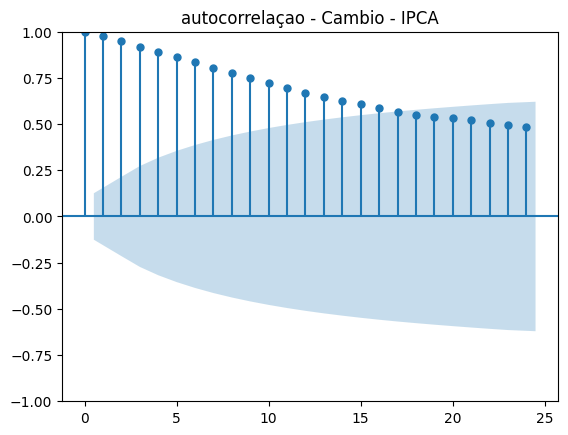

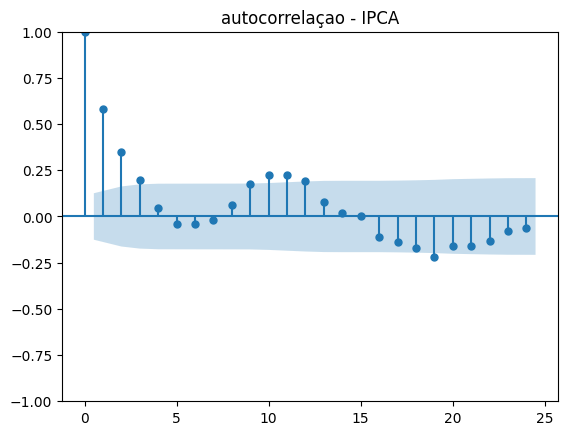

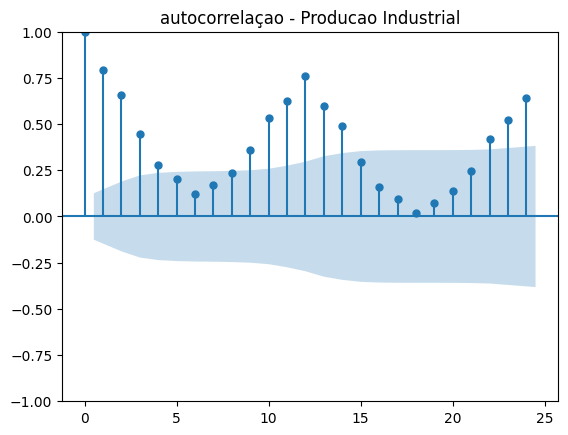

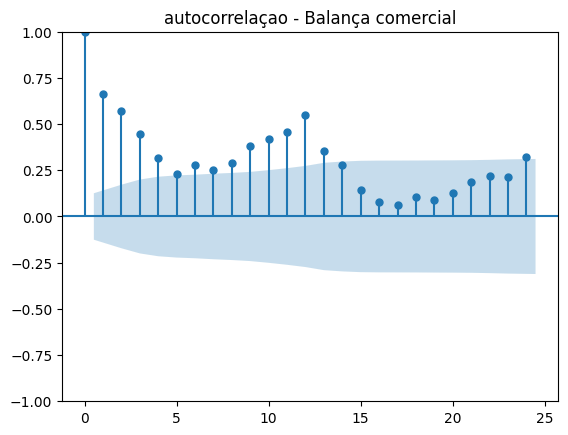

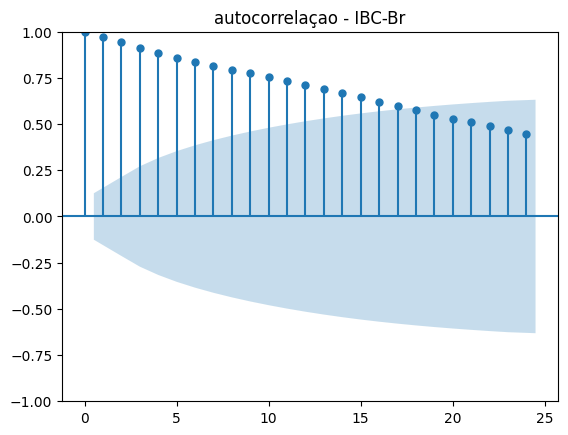

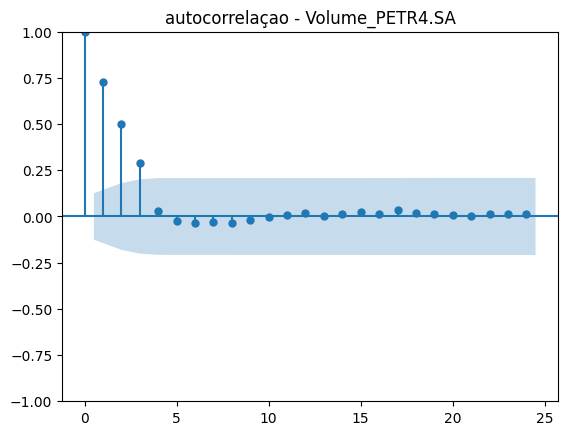

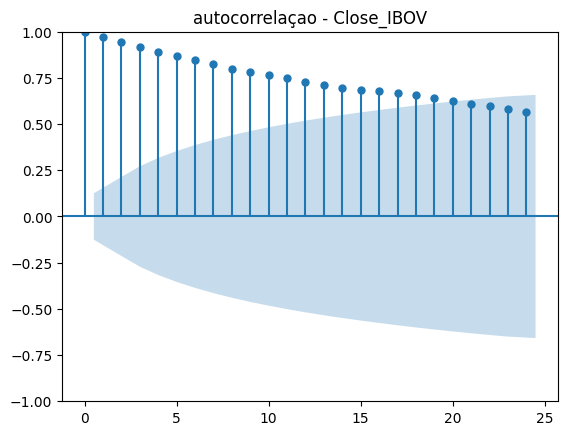

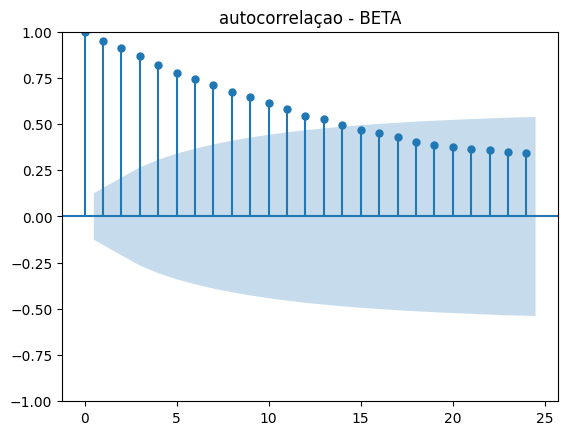

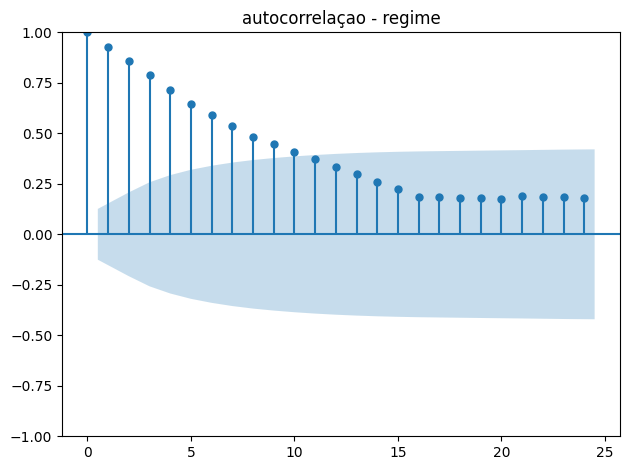

In [14]:
from statsmodels.graphics. tsaplots import plot_acf
for i in X_train.columns:
    plot_acf(x=X_train[i], title=f"autocorrelaçao - {i}")
plt.tight_layout()
plt.show()

# Treinamento 

In [15]:
# funçao para metricas
def metrics(y_true:pd.Series, y_pred:pd.Series) -> pd.DataFrame:
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    metrics_dict = {
        "MAE": mae, 
        "MSE": mse, 
        "R2": r2
    }
    return pd.DataFrame([metrics_dict])

Modelo Arvore_de_decisao

 metricas Treino ->    MAE  MSE   R2
0  0.0  0.0  1.0
 metricas Teste ->         MAE      MSE        R2
0  0.047317  0.00357 -1.479181


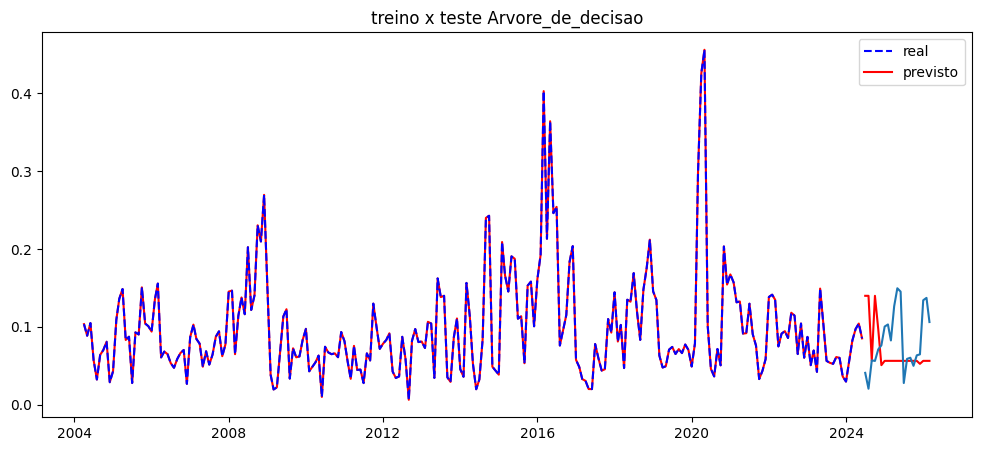

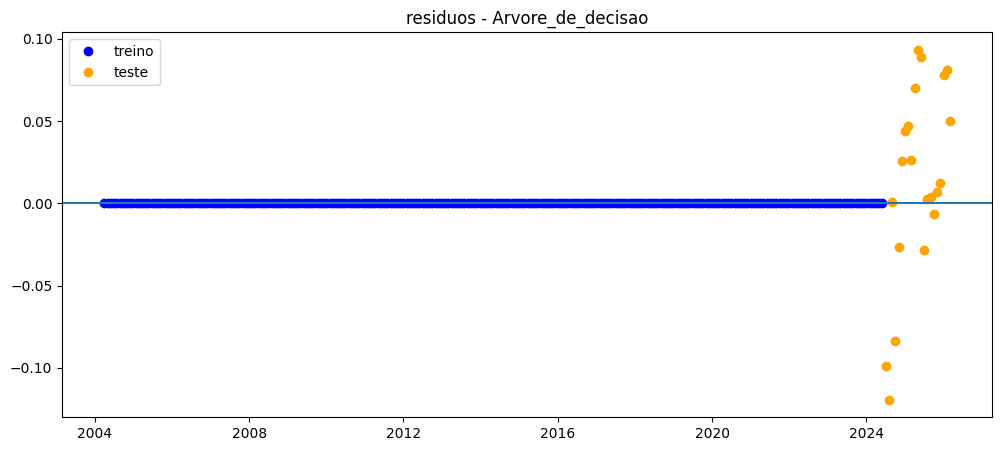

-0.1680493571081192
Modelo Gradient_Boosting

 metricas Treino ->         MAE       MSE        R2
0  0.016571  0.000434  0.901481
 metricas Teste ->         MAE       MSE        R2
0  0.035923  0.002056 -0.427768


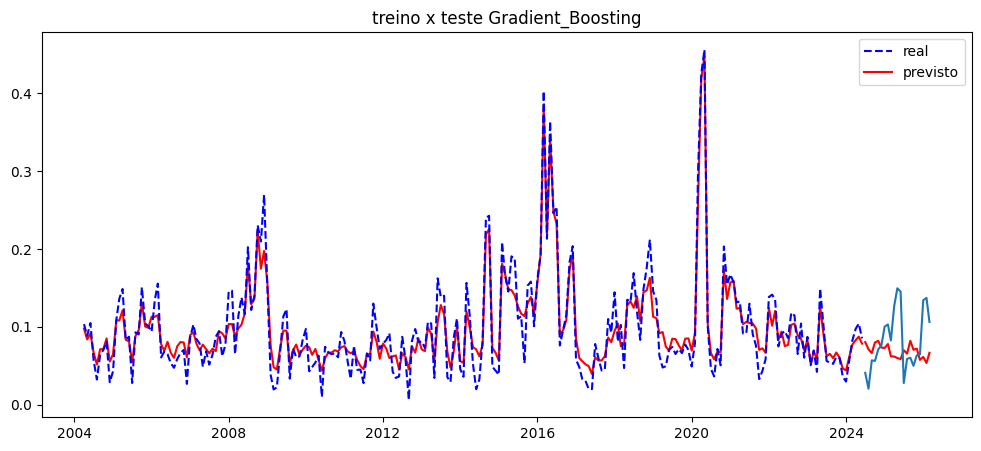

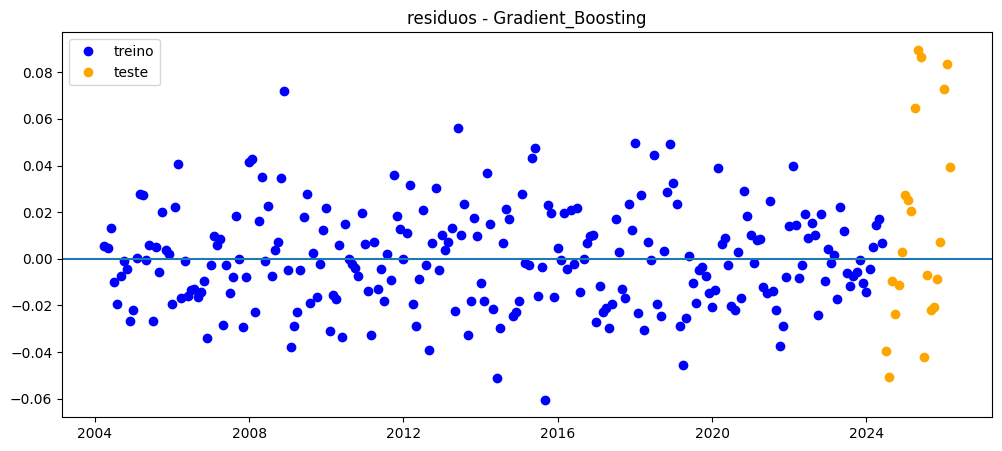

-0.1680493571081192
Modelo XGBoost

 metricas Treino ->         MAE           MSE        R2
0  0.000592  6.714729e-07  0.999848
 metricas Teste ->         MAE     MSE        R2
0  0.038898  0.0025 -0.735892


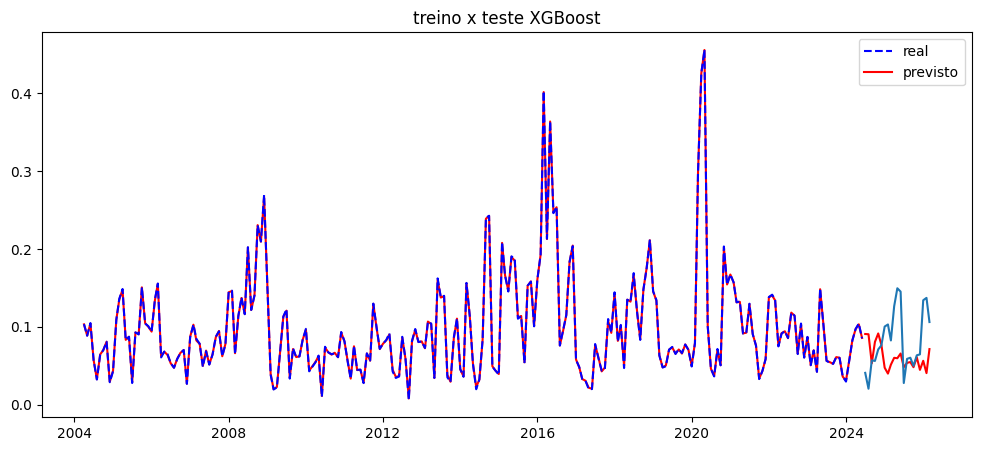

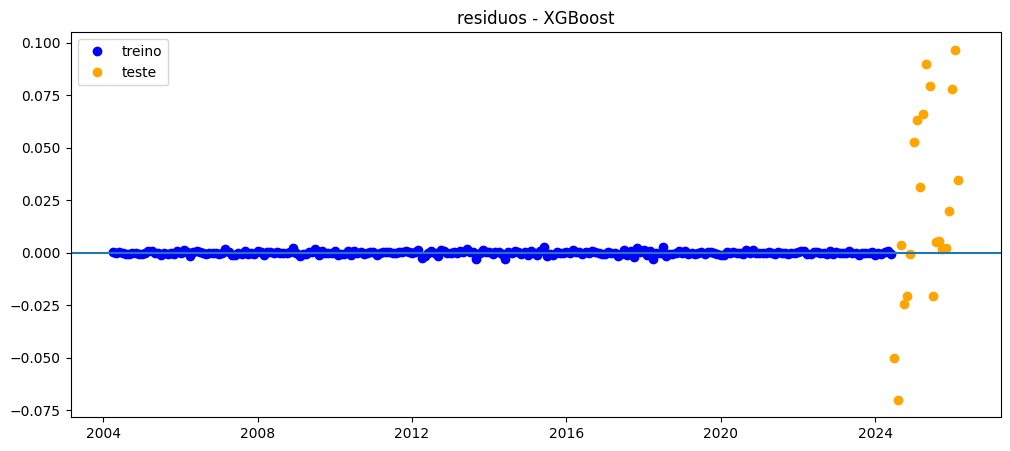

-0.1680493571081192
Modelo AdaBoost

 metricas Treino ->         MAE       MSE        R2
0  0.030802  0.001342  0.695549
 metricas Teste ->         MAE       MSE        R2
0  0.028183  0.001217  0.154881


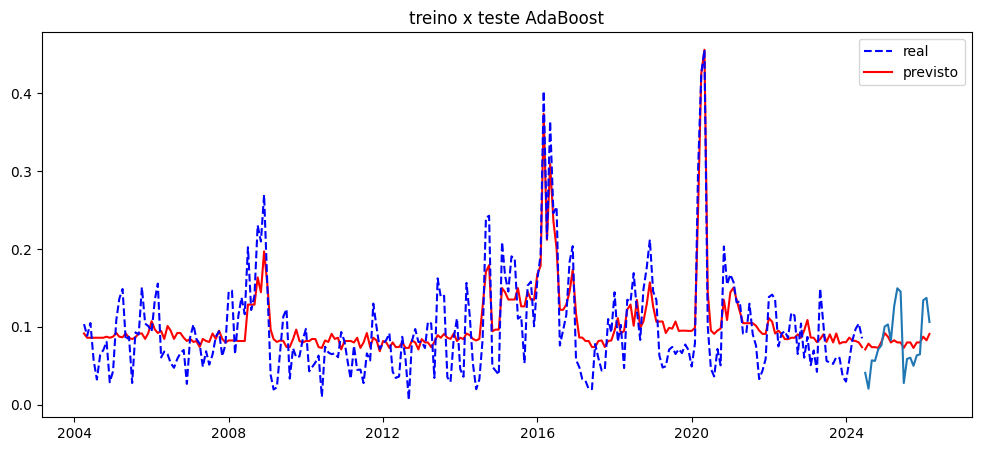

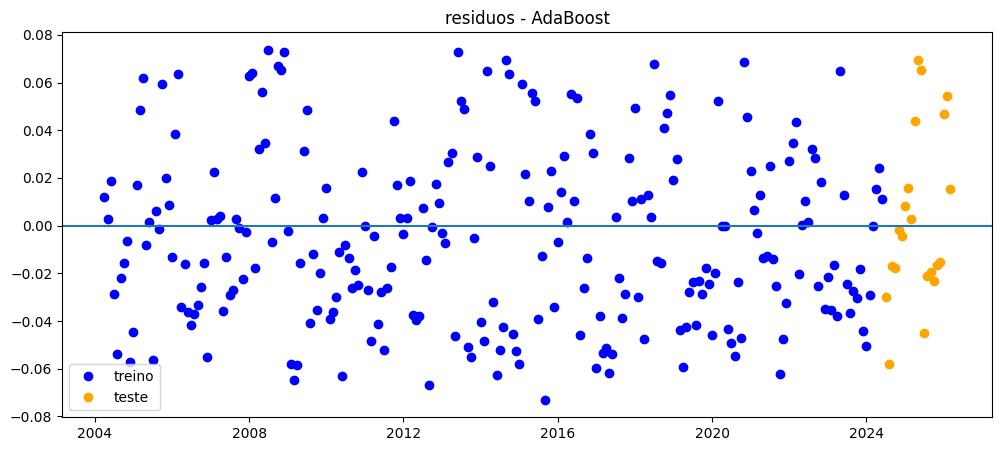

-0.1680493571081192


In [16]:
for i, model in models.items():
    model_ = model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print("==="*20)
    print(f"Modelo {i}")
    print()
    print(f" metricas Treino -> {metrics(y_train, y_pred_train)}")
    print(f" metricas Teste -> {metrics(y_test, y_pred_test)}")
    
    plt.figure(figsize=(12,5))
    plt.title(f'treino x teste {i}')
    plt.plot(y_train.index, y_pred_train, color='red')
    plt.plot(y_train, linestyle='--', color='blue', label='real')
    plt.plot(y_test.index, y_pred_test, color='red', label='previsto')
    plt.plot(y_test)
    plt.legend()
    plt.show()
    
    # calculando residuo 
    resid_train = y_train - y_pred_train
    resid_test = y_test - y_pred_test
    plt.figure(figsize=(12,5))
    plt.title(f'residuos - {i}')
    plt.plot(resid_train, linestyle='none', marker='o', color='blue', label='treino')
    plt.plot(resid_test, linestyle='none', marker='o', color='orange', label='teste')
    plt.axhline(y=0)        
    plt.legend()
    plt.show()
    
    y_pred_baseline = np.full_like(y_test, y_train.mean())

    print(r2_score(y_test, y_pred_baseline))

# Modelo ARDL 

In [17]:
model_ardl = ARDL(y_train, lags=3, exog=X_train, order=2).fit()
print(model_ardl.summary())

                                            ARDL Model Results                                            
Dep. Variable:                                              sigma   No. Observations:                  243
Model:             ARDL(3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)   Log Likelihood                 414.127
Method:                                           Conditional MLE   S.D. of innovations              0.043
Date:                                            Thu, 28 May 2026   AIC                           -740.254
Time:                                                    14:43:12   BIC                           -587.106
Sample:                                                07-01-2004   HQIC                          -678.547
                                                     - 06-01-2024                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------

as features que realmente se mostraram significativas no ARDL sao: IBC-Br e BETA. O restante se tornou ruido 

In [18]:
select_cols = ['IBC-Br', 'BETA']
X_select = X_train[select_cols]
new_ardl = ARDL(endog=y_train, lags=[1,3],exog=X_select, order=1, trend='n').fit()
print(new_ardl.summary())

                              ARDL Model Results                              
Dep. Variable:                  sigma   No. Observations:                  243
Model:                  ARDL(3, 1, 1)   Log Likelihood                 391.478
Method:               Conditional MLE   S.D. of innovations              0.047
Date:                Thu, 28 May 2026   AIC                           -768.956
Time:                        14:43:12   BIC                           -744.591
Sample:                    07-01-2004   HQIC                          -759.139
                         - 06-01-2024                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma.L1       0.5717      0.051     11.216      0.000       0.471       0.672
sigma.L3      -0.1535      0.052     -2.962      0.003      -0.256      -0.051
IBC-Br.L0     -0.0155      0.003     -5.346      0.0

Com a poda do modelo e das features, consegui metricas melhores e mais ajustadas: 

- p_valores significativos 

- persistencia temporal entre os lags 

- aic e bic consistentes

# Previsoes ARDL

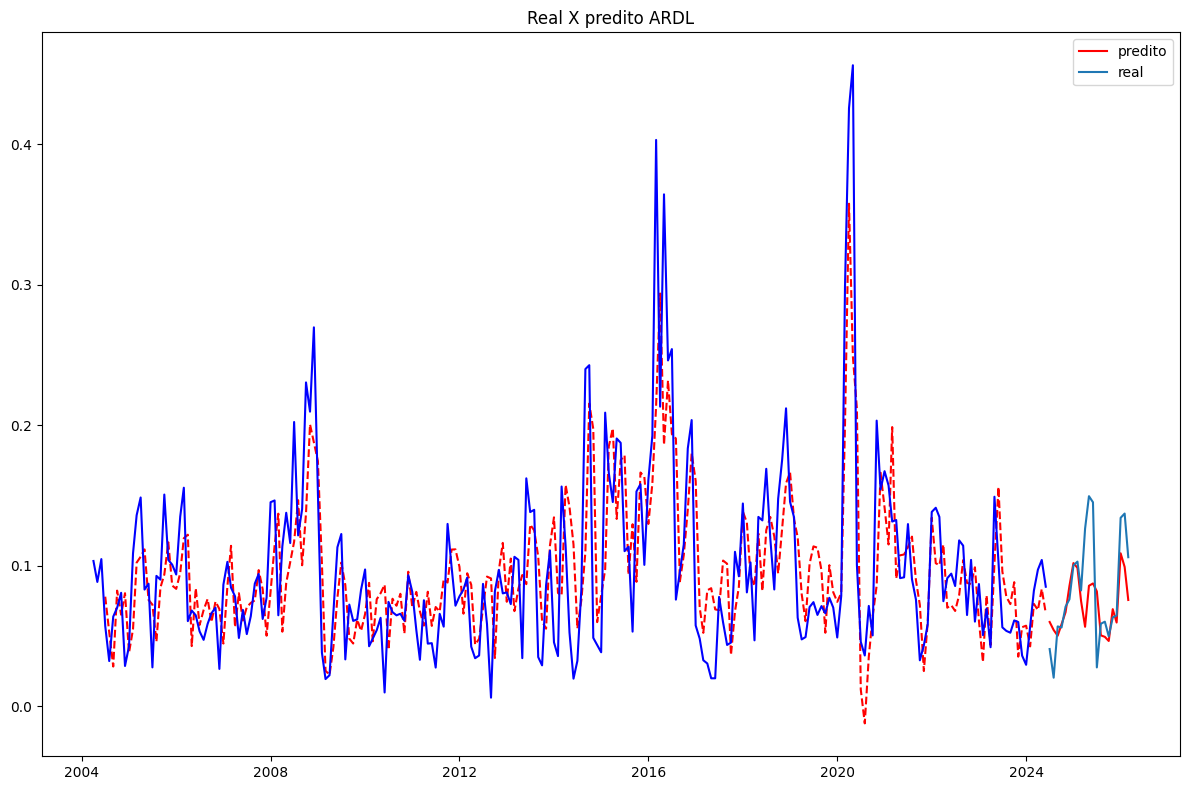

metricas - ardl
        MAE       MSE        R2
0  0.021965  0.000962  0.331669


In [19]:
pred_ardl = new_ardl.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog_oos=X_test[select_cols])
pred_train_ardl = new_ardl.predict(start=0, end=len(y_train)-1, exog=X_train[select_cols])

plt.figure(figsize=(12,8))
plt.title("Real X predito ARDL")
plt.plot(pred_train_ardl, color='red', linestyle='--')
plt.plot(y_train, color='blue')
plt.plot(pred_ardl, label='predito', color='red')
plt.plot(y_test, label='real')
plt.tight_layout()
plt.legend()
plt.show()

print(f"metricas - ardl")
print(metrics(y_test, pred_ardl))

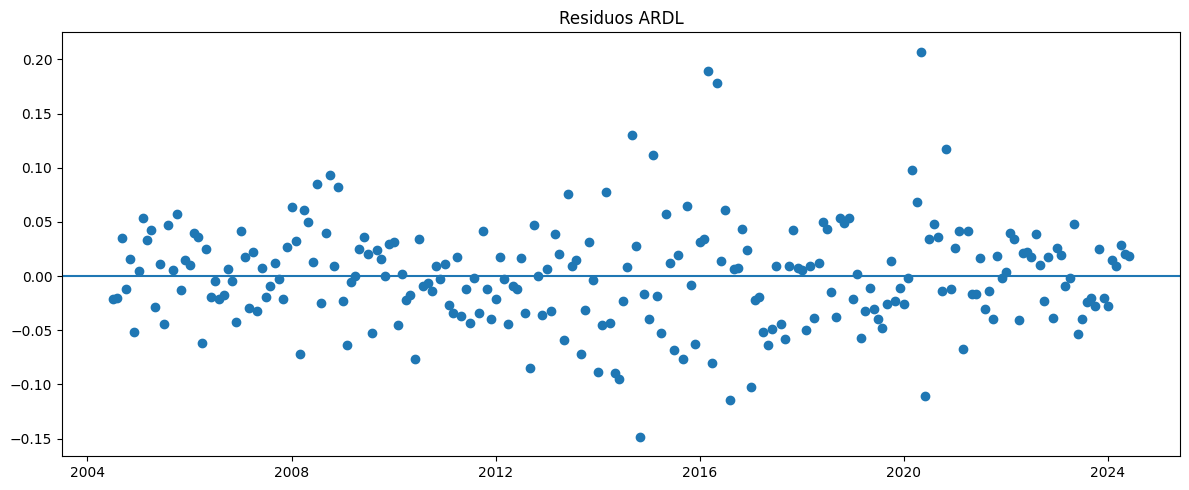

<Figure size 1200x500 with 0 Axes>

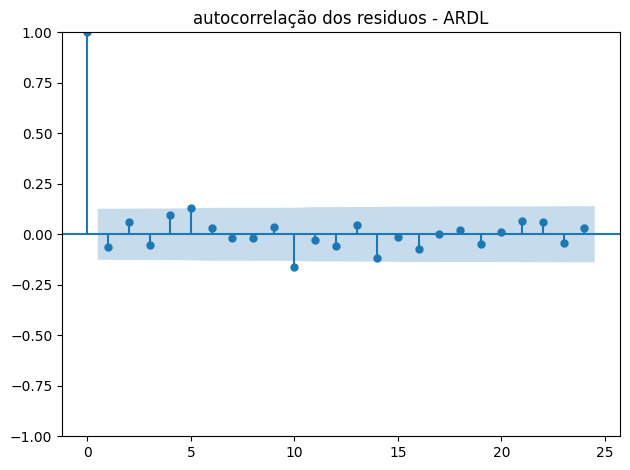

In [20]:
# residuos e autocorrelaçao dos residuos 
n = new_ardl.resid
plt.figure(figsize=(12,5))
plt.title('Residuos ARDL')
plt.plot(n, marker='o', linestyle='none')
plt.axhline(y=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plot_acf(n, title='autocorrelação dos residuos - ARDL')
plt.tight_layout()
plt.show()

# Teste de Heterocesdasticidade

Se p_valor > 0.05 -> Não rejeita a hipotese nula (há heterocedasticidade)

Se p_valor < 0.05 -> Rejeita a hipotese nula (não há heterocedasticidade)

In [21]:
# het_breuschpagan
def het_breuschpagan_test(resid:pd.Series, exog) -> pd.DataFrame:
    resid = pd.Series(resid)
    df = pd.concat([resid, exog], axis=1).dropna()
    exog_clean = df.iloc[:, 1:]
    resid_clean = df.iloc[:, 0]
    lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(resid_clean,sm.add_constant(exog_clean), robust=True)
    if lm_pvalue < 0.05 and f_pvalue <0.05:
        print('hipotese nula rejeitada -> Não há evidencias estatisticas de heterocedasticidade')
    else:
        print('hipotese nula aceita -> Há evidencias estatisticas de heterocedasticidade')
    out_test = {
        'lm':lm, 
        'lm_pvalue':lm_pvalue,
        'fvalue':fvalue, 
        'f_pvalue': f_pvalue
    }
    return pd.DataFrame([out_test])

In [22]:
het_breuschpagan_test(new_ardl.resid, X_train[select_cols])

hipotese nula rejeitada -> Não há evidencias estatisticas de heterocedasticidade


,lm,lm_pvalue,fvalue,f_pvalue
0,27.948223,8.533368e-07,15.618188,4.249472e-07


# Verificando normalidade dos residuos

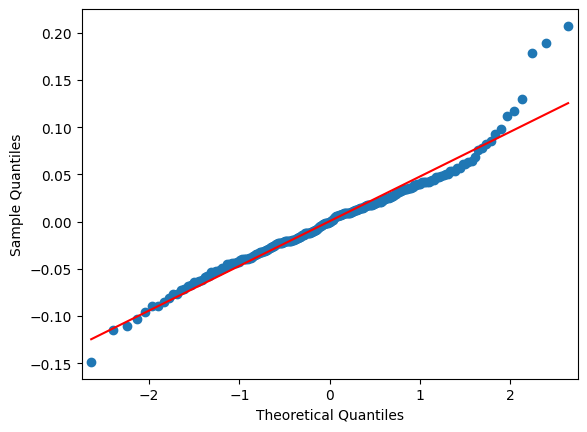

In [23]:
# qq plot 
fig_qq = qqplot(new_ardl.resid, line='s')
fig_qq.show()


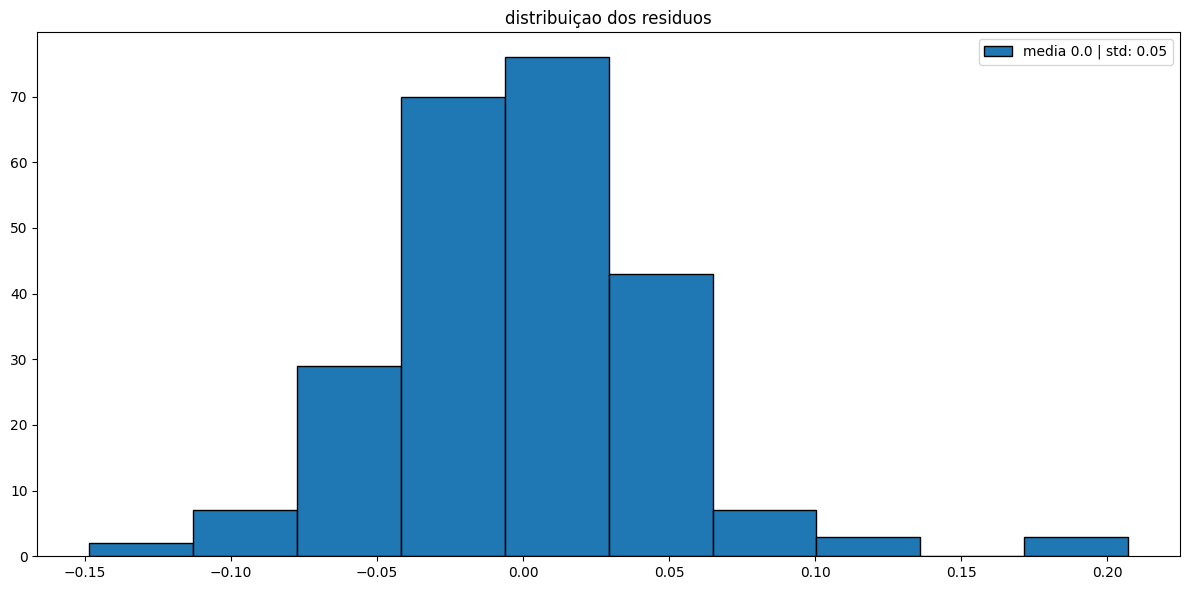

In [24]:
# distribuiçao dos residuos
fig = plt.figure(figsize=(12,6))
plt.title('distribuiçao dos residuos')
plt.hist(new_ardl.resid, edgecolor='black', label=f'media {np.round(np.mean(n),2)} | std: {np.round(np.std(n),2)}')
plt.legend()
plt.tight_layout()
plt.show()

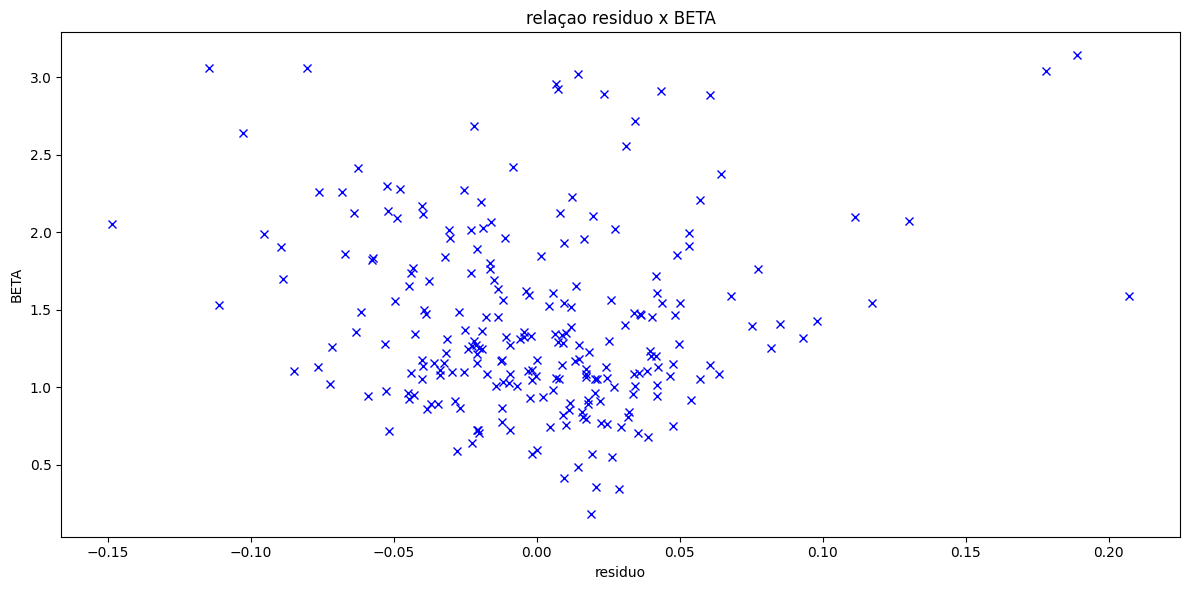

In [25]:
# comparando residuo com o beta para verificar linearidade
df_ = pd.concat([n, X_select], axis=1).dropna()
plt.figure(figsize=(12,6))
plt.title('relaçao residuo x BETA')
plt.plot(df_[0], df_['BETA'], marker='x', linestyle='none', color='blue')
plt.xlabel('residuo')
plt.ylabel('BETA')

plt.tight_layout()
plt.show()

Não há linearidade entre os residuos e o BETA

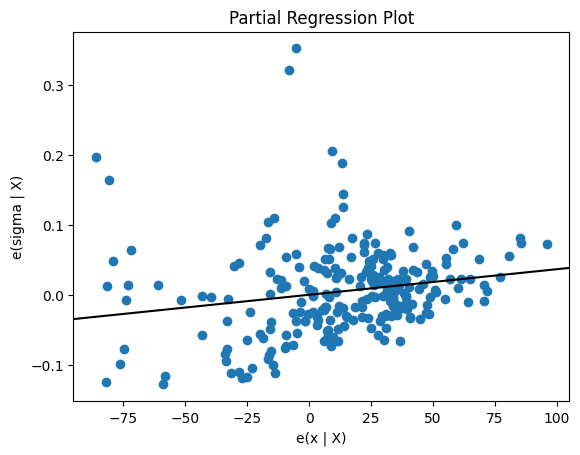

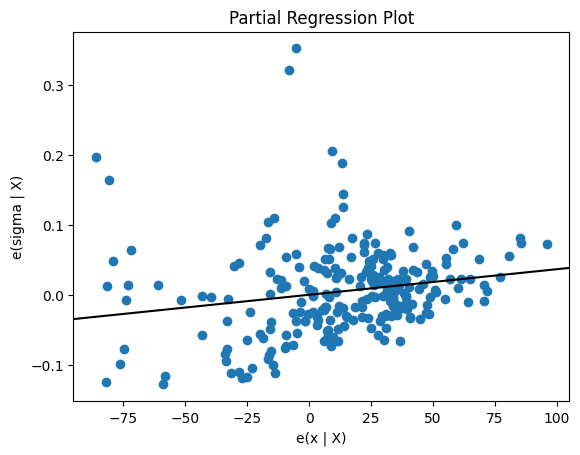

In [26]:
sm.graphics.plot_partregress(y_train, new_ardl.model.exog[:,0], new_ardl.model.exog[:,1:], obs_labels=False)


# Jarque Bera

Se o valor de Jarque bera estiver muito distante de 0, indica que os dados nao seguem uma distribuiçao normal

In [27]:
from scipy.stats import jarque_bera

print("---- Teste Jarque Bera ----")
print()
jb_pvalue = jarque_bera(new_ardl.resid)[1]
jb_stats = jarque_bera(new_ardl.resid)[0]
print(f'pvalor -> {jb_pvalue}')
print()
if jb_pvalue <0.05:
    print('{Hipotese nula rejeitada H[0] -> Não há evidencias de normalidade por Jarque Bera -> H[1]}')
else: 
    print('Hipotese nula aceita H[0]-> Há evidencias de normalidade por Jarque Bera -> H[0]')
print()
print(f'Valor de Jarque Bera -> {jb_stats}')
print('----'*50)

---- Teste Jarque Bera ----

pvalor -> 1.4345401641367647e-20

{Hipotese nula rejeitada H[0] -> Não há evidencias de normalidade por Jarque Bera -> H[1]}

Valor de Jarque Bera -> 91.38171501026493
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


 Avaliando o modelo pelos acertos -> Medido pelos atrasos reais/preditos e pela média global do valor real

In [28]:
results = X_test[['IBC-Br', 'BETA']].copy()
results['real'] = y_test
results['pred'] = pred_ardl
results['real_lag'] = results['real'].shift(1)
results['pred_lag'] = results['pred'].shift(1)

# criando labels 
results['real_dir'] = np.where(results['real']>results['real_lag'], 1, 0)
results['pred_dir'] = np.where(results['pred']>results['pred_lag'], 1,0)
results['real_cat'] = np.where(results['real']>results['real'].mean(),1,0)
results['pred_cat'] = np.where(results['pred']>results['real'].mean(),1,0)

In [29]:
results

,IBC-Br,BETA,real,pred,real_lag,pred_lag,real_dir,pred_dir,real_cat,pred_cat
data,,,,,,,,,,
2024-07-01,106.92867,0.071381,0.040796,0.060035,NaN,NaN,0,0,0,0
2024-08-01,107.11857,0.098707,0.020413,0.054317,0.040796,0.060035,0,0,0,0
2024-09-01,108.03396,0.247604,0.056877,0.050246,0.020413,0.054317,1,0,0,0
2024-10-01,108.19846,0.254160,0.056121,0.058441,0.056877,0.050246,0,1,0,0
2024-11-01,107.99158,0.208590,0.070912,0.066971,0.056121,0.058441,1,1,0,0
2024-12-01,107.08370,0.218672,0.076192,0.085617,0.070912,0.066971,1,1,0,1
2025-01-01,108.32040,0.933045,0.100314,0.101924,0.076192,0.085617,1,1,1,1
2025-02-01,108.91950,1.029649,0.102982,0.098537,0.100314,0.101924,1,0,1,1
2025-03-01,109.83267,0.847244,0.082462,0.074920,0.102982,0.098537,0,0,1,0


In [30]:
results_cross  = round(pd.crosstab(results.pred_cat, results.real_cat, normalize=True)*100,2)
results_cross

real_cat,0,1
pred_cat,,
0,52.38,14.29
1,4.76,28.57


In [31]:
print('---'*20)
print(f'volatilidade média : {round(y_test.mean(),3)}')
print(f'volatilidade média prevista {round(pred_ardl.mean(),3)}')
print()
print(f"o modelo consegue acertar {results_cross[0][0] +results_cross[1][1]}% dos casos")
print('---'*20)


------------------------------------------------------------
volatilidade média : 0.082
volatilidade média prevista 0.072

o modelo consegue acertar 80.95% dos casos
------------------------------------------------------------


# Estudo de Volatidade 

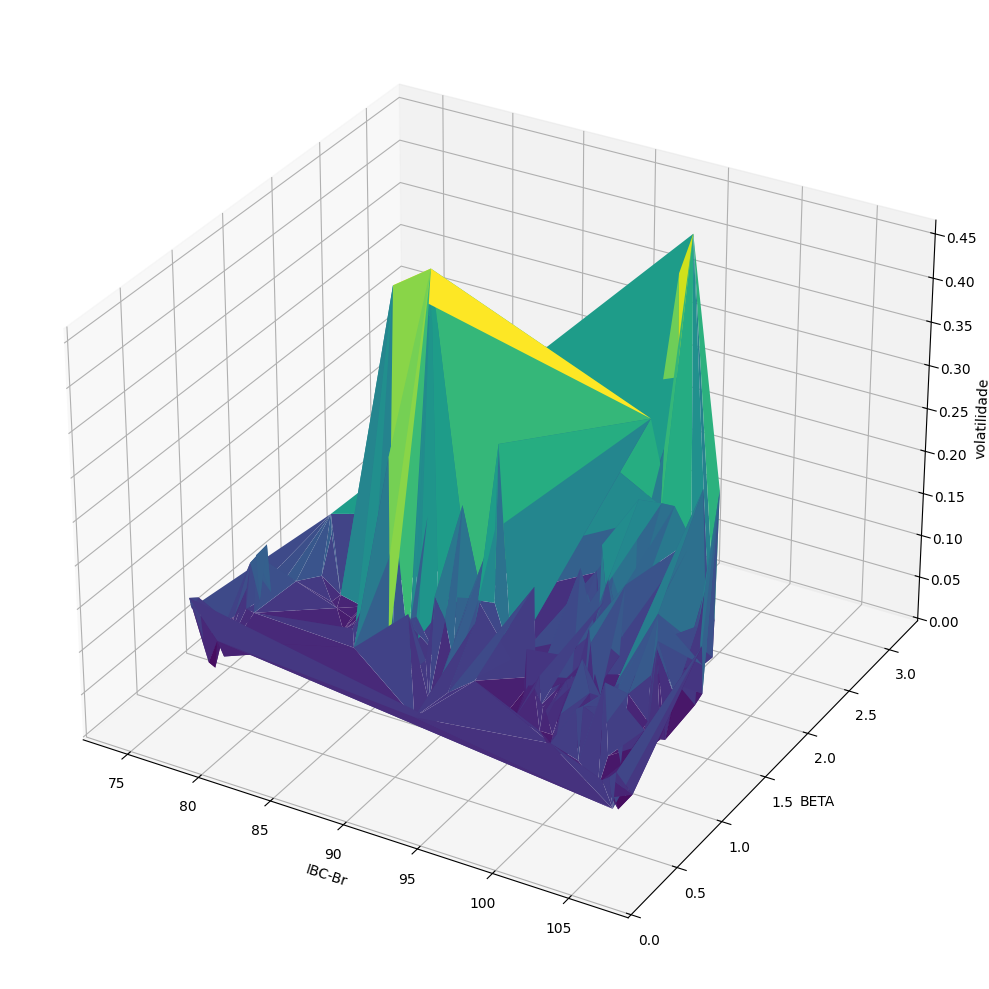

In [32]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(X_train['IBC-Br'].values, X_train['BETA'].values, y_train.values, cmap='viridis', lightsource=True)
ax.set_xlabel('IBC-Br')
ax.set_ylabel('BETA')
ax.set_zlabel('volatilidade')
fig.tight_layout()
fig.show()

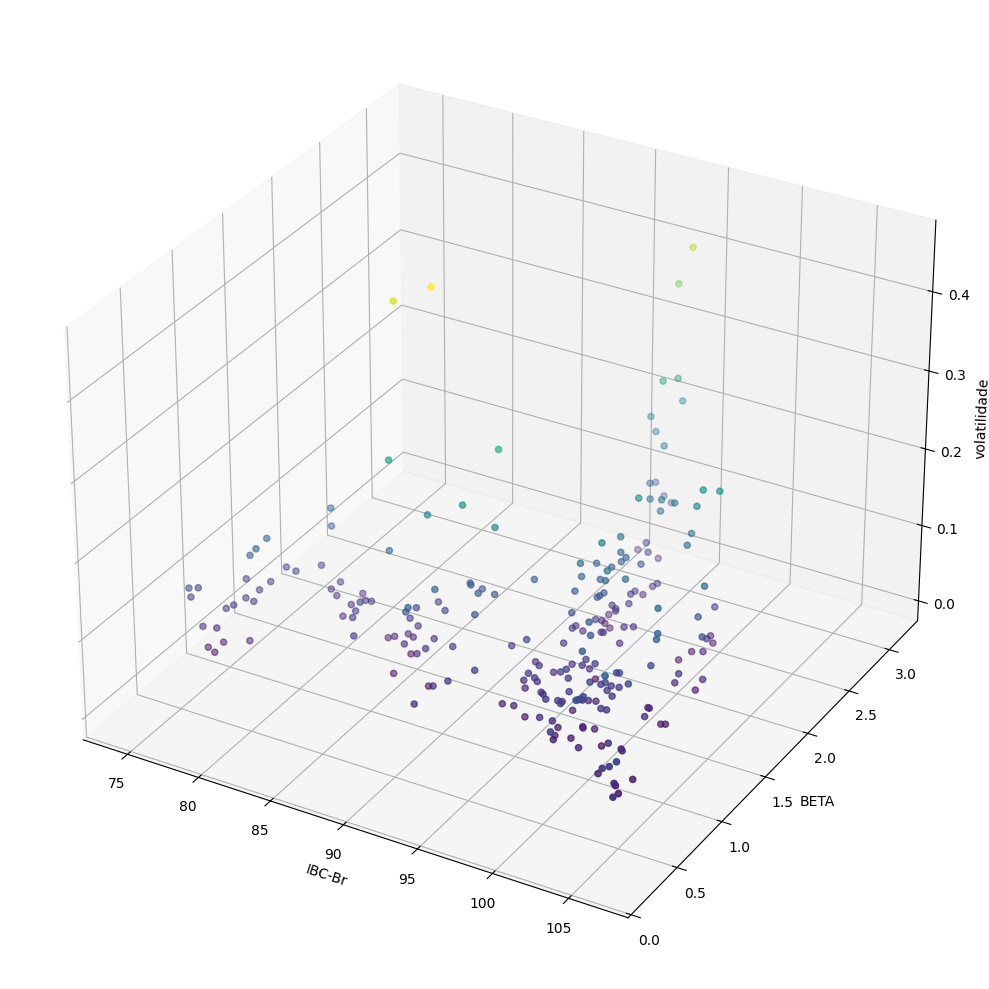

In [33]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train['IBC-Br'].values, X_train['BETA'].values, y_train.values, cmap='viridis', c=y_train.values)
ax.set_xlabel('IBC-Br')
ax.set_ylabel('BETA')
ax.set_zlabel('volatilidade')
fig.tight_layout()
fig.show()

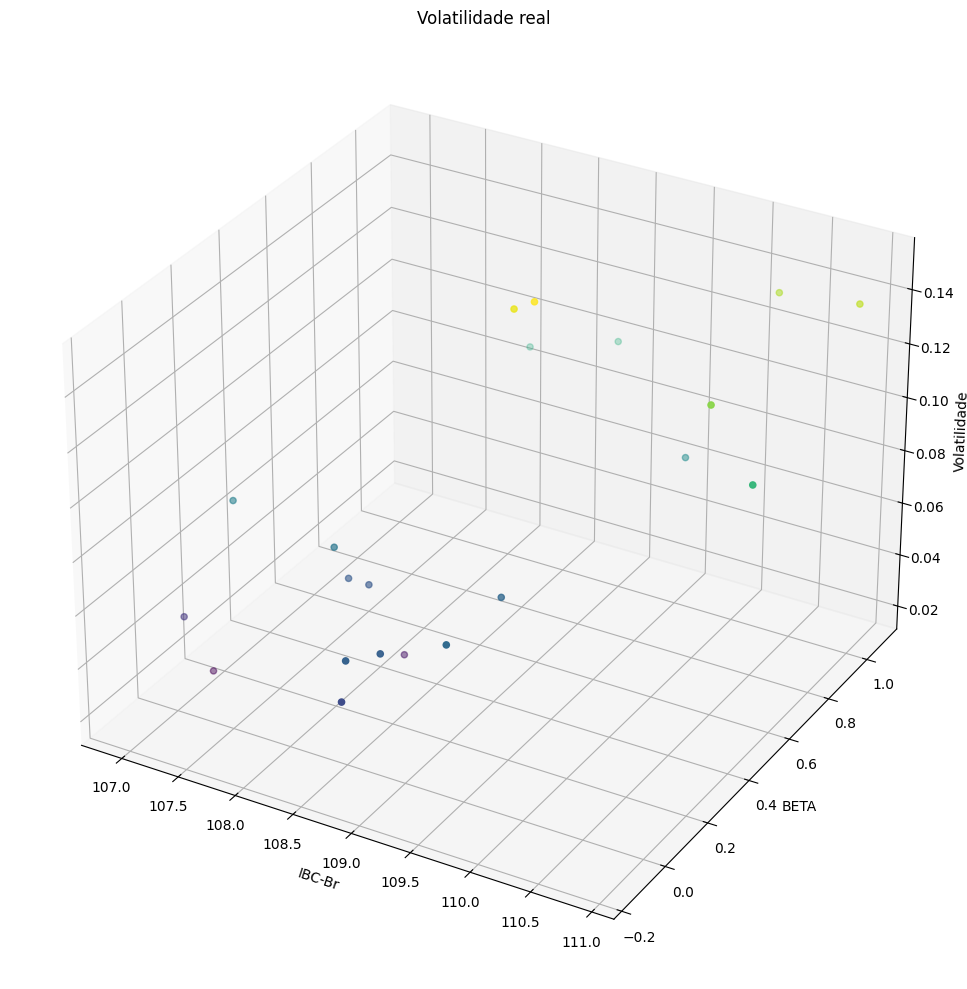

In [34]:

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Volatilidade real')
ax.scatter(X_test['IBC-Br'].values, X_test['BETA'].values, y_test.values, c=y_test.values)

ax.set_xlabel('IBC-Br')
ax.set_ylabel('BETA')
ax.set_zlabel('Volatilidade')
fig.tight_layout()

In [35]:
study =pd.concat([X_test, y_test], axis=1)
study[study['BETA']>1]

,Produção de derivados de petróleo,Consumo de derivados de petróleo - gasolina,Consumo de derivados de petróleo - Óleo combustível,Selic,Cambio - IPCA,IPCA,Producao Industrial,Balança comercial,IBC-Br,Volume_PETR4.SA,Close_IBOV,BETA,regime,sigma
data,,,,,,,,,,,,,,
2025-02-01,3488.0,560.0,25.0,0.99,130.95,1.31,93.5,-1122.8,108.91950,674268300,122799.0,1.029649,0.0,0.102982
2026-01-01,3953.0,580.0,17.0,1.16,123.71,0.33,95.2,2907.0,110.22869,961223500,181364.0,1.064134,0.0,0.134139
2026-02-01,4061.0,617.0,16.0,1.00,122.21,0.70,92.8,3337.3,110.89057,697767300,188787.0,1.070226,0.0,0.137161


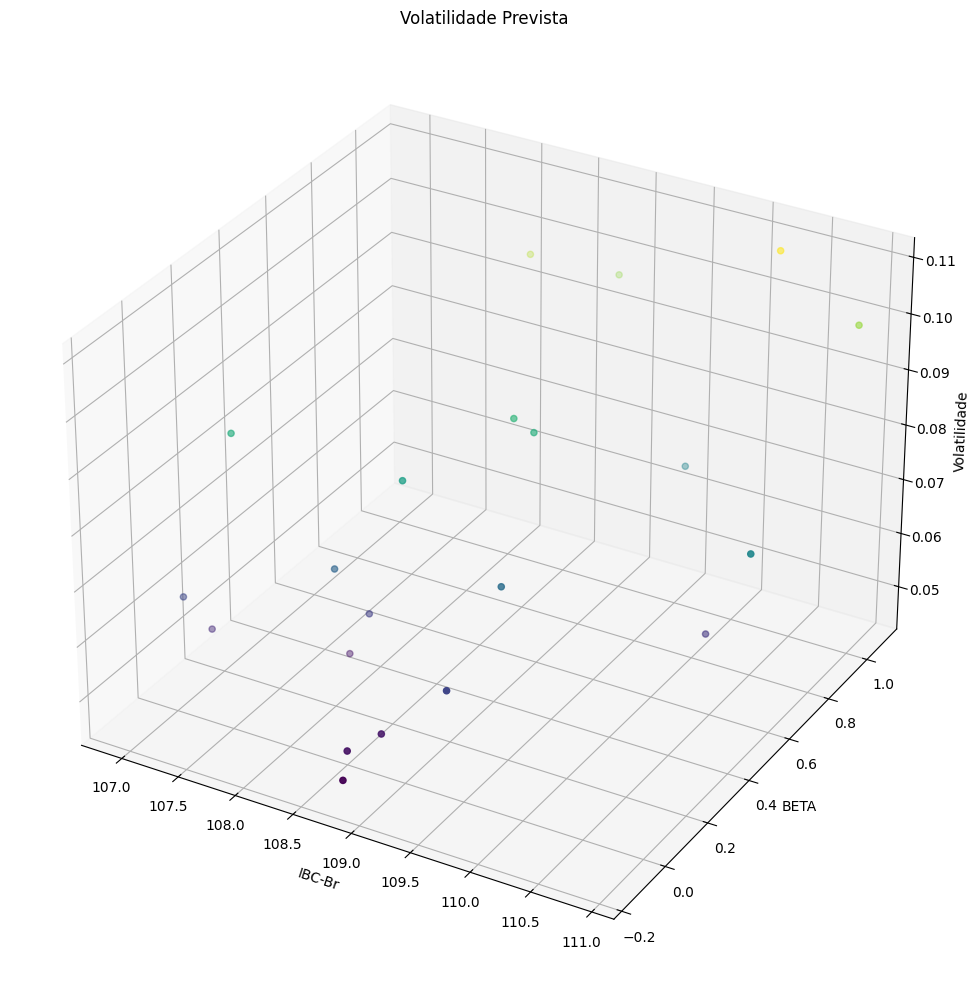

In [36]:

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Volatilidade Prevista')
ax.scatter(X_test['IBC-Br'].values, X_test['BETA'].values, pred_ardl.values, c=pred_ardl.values)

ax.set_xlabel('IBC-Br')
ax.set_ylabel('BETA')
ax.set_zlabel('Volatilidade')
fig.tight_layout()

In [37]:
# exportando o modelo 
model_path = os.path.join('..', 'modelARDL.pkl')
joblib.dump(new_ardl, model_path)

['..\\modelARDL.pkl']

In [38]:
# simulando cenarios de normalidade
X_mc = df_test[select_cols]
mc_normal = MonteCarlo(X_mc).normal_scenario(30000)
mc_normal 

,IBC-Br,BETA
0,111.018004,0.831158
1,108.906517,0.454230
2,111.023857,0.508967
3,107.846062,-0.303539
4,110.552894,0.122492
...,...,...
29995,109.250127,0.769665
29996,107.090849,0.661470
29997,109.561523,0.590662
29998,107.042260,0.615953


In [39]:
# debudgndo problema de data ardl 
new_ardl.model.data.dates = None
new_ardl.model.data.freq = None
new_ardl.model._index = pd.RangeIndex(len(y_train))
new_ardl.model._index_generated = False
new_ardl._index = pd.RangeIndex(start=0, stop=len(df))


# Simulaçao - Cenário normal 

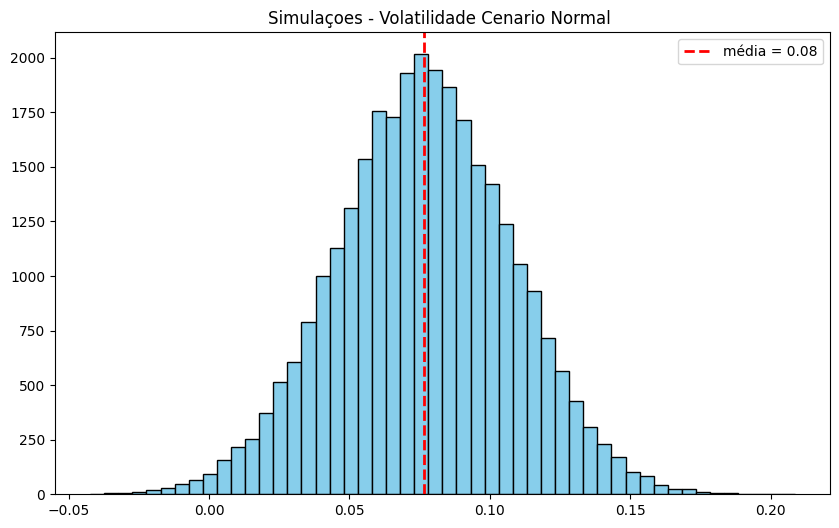

In [40]:
pred_mc_normal = new_ardl.predict(start=len(y_train), end=len(y_train)+len(mc_normal)-1, exog_oos=mc_normal)
plt.figure(figsize=(10,6))
plt.title('Simulaçoes - Volatilidade Cenario Normal ')
plt.hist(pred_mc_normal, bins=50, edgecolor='black', color='skyblue')
plt.axvline(pred_mc_normal.mean(), color='red', linestyle='dashed', linewidth=2, label=f'média = {round(pred_mc_normal.mean(),2)}')
plt.legend()
plt.show()

Simulaçao - Cenario de Estresse -> IBC-Br baixo mas o beta nao varia

In [41]:
ibc_br_low = MonteCarlo(X_mc).sim_scenario(30000, -3, 'IBC-Br')
ibc_br_low.mean()

IBC-Br    105.588895
dtype: float64

In [42]:
mc_normal

,IBC-Br,BETA
0,111.018004,0.831158
1,108.906517,0.454230
2,111.023857,0.508967
3,107.846062,-0.303539
4,110.552894,0.122492
...,...,...
29995,109.250127,0.769665
29996,107.090849,0.661470
29997,109.561523,0.590662
29998,107.042260,0.615953


In [43]:
ibc_br_low['BETA'] = mc_normal['BETA']
ibc_br_low

,IBC-Br,BETA
0,104.692249,0.831158
1,104.415141,0.454230
2,105.722023,0.508967
3,104.452197,-0.303539
4,104.410829,0.122492
...,...,...
29995,107.428174,0.769665
29996,105.511586,0.661470
29997,105.523855,0.590662
29998,104.688138,0.615953


In [44]:
pred_ibc_low= new_ardl.predict(start=len(y_train), end=len(y_train)+len(ibc_br_low)-1, exog_oos=ibc_br_low) 
print('--- Diagnosticos ---')
print()
print(f"média real -> {y_test.mean()} -> std: {y_test.std()}")
print(f'média prevista -> {pred_ibc_low.mean()} -> std: {pred_ibc_low.std()}')

--- Diagnosticos ---

média real -> 0.08238528653380751 -> std: 0.0388837323864654
média prevista -> 0.07474499226157204 -> std: 0.03044743708461845


Com a economia em baixam (3%), o mercado de ativos tende a se retrair e a area de compra e vendas de ativos se torna restrita, fazendo a volatidade retrair. 

Podemos ver esse comportamento no grafico abaixo: 



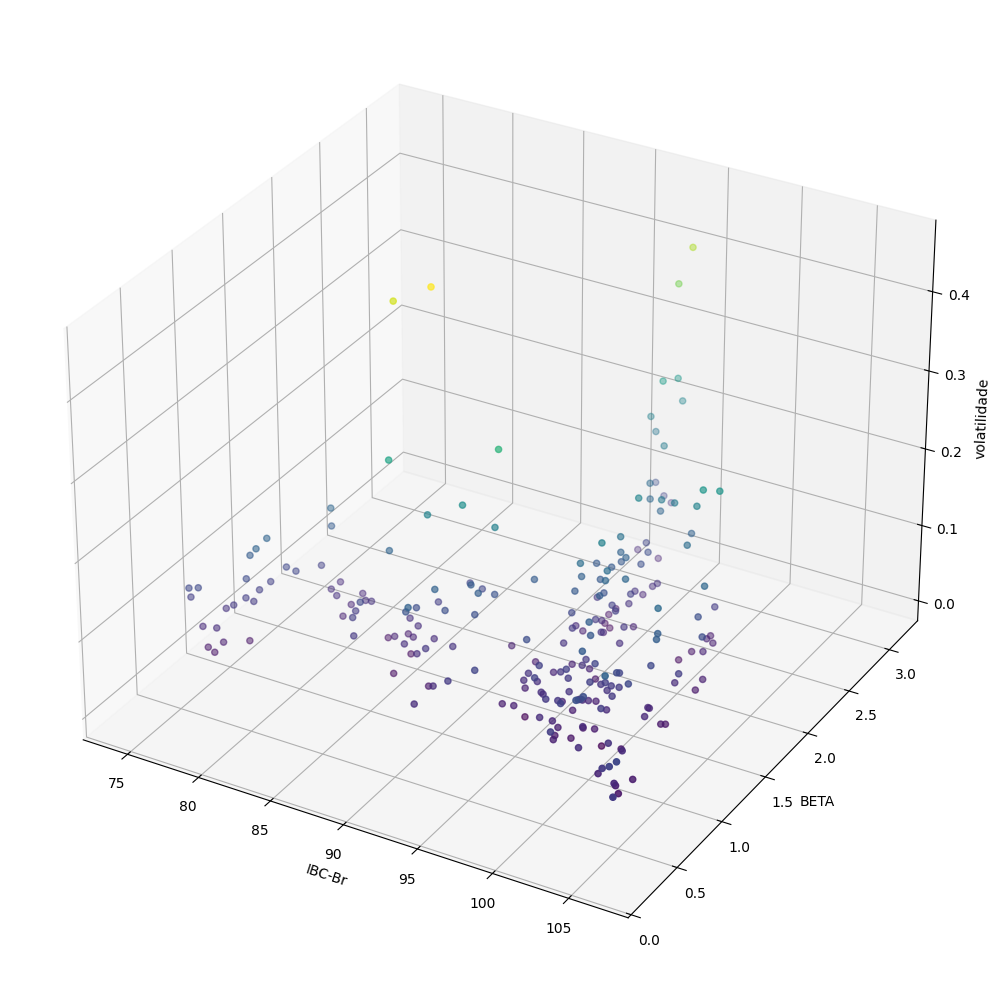

# Realizando Simulações em Conjunto

IBC-Br em crescente + BETA em crescente

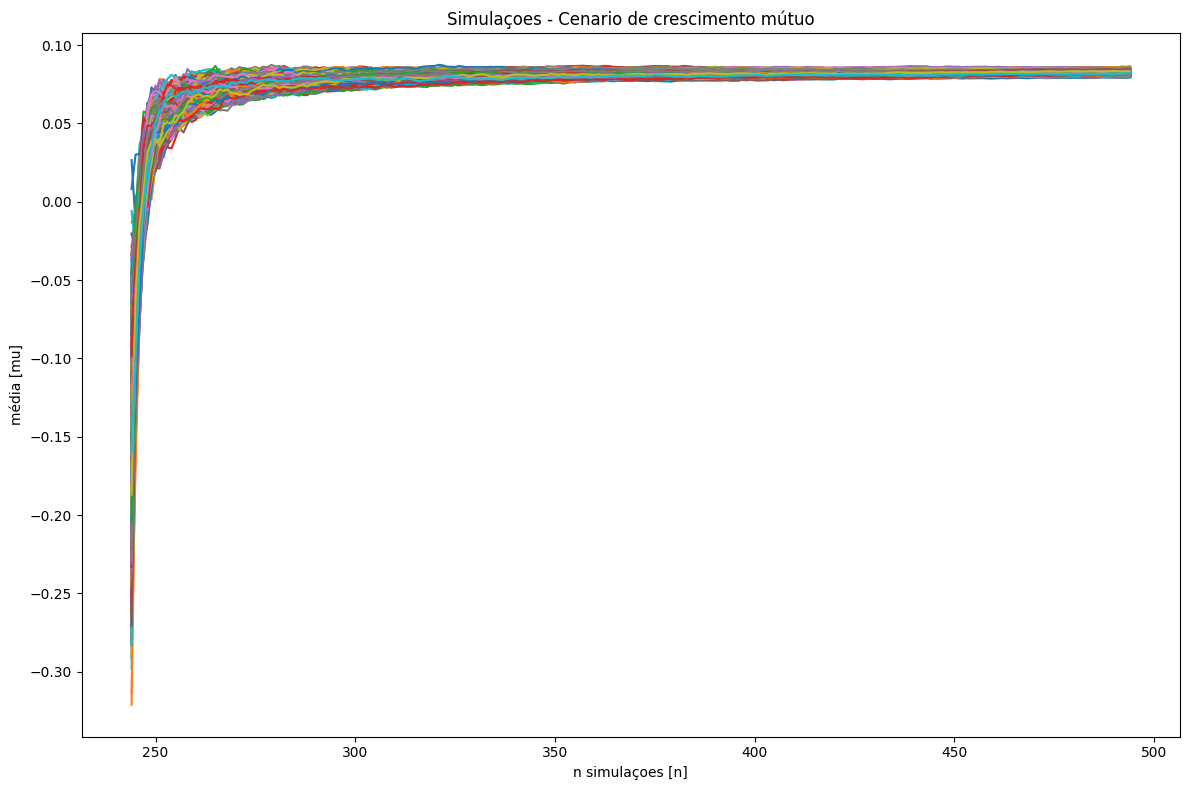

In [45]:
scenarios = 252
sim = 10000
plt.figure(figsize=(12,8))
plt.title('Simulaçoes - Cenario de crescimento mútuo')
mean_high = []
for i in range(sim):
    beta_ = MonteCarlo(X_mc).sim_scenario(scenarios, 5, 'BETA')
    ibc_br_high = MonteCarlo(X_mc).sim_scenario(scenarios, 10, 'IBC-Br')
    df_high = pd.concat([ibc_br_high, beta_], axis=1)
    pred_high = new_ardl.predict(start=len(y_train),end=len(y_train)+len(df_high)-1,exog_oos=df_high)
    y_hat = np.cumsum(pred_high)/np.arange(len(pred_high))
    mean_high.append(pred_high)
    plt.plot(y_hat)
plt.xlabel('n simulaçoes [n]')
plt.ylabel('média [mu]')
plt.tight_layout()
plt.show()

In [46]:
mean_high = np.array(mean_high)
print('===='*20)
print(f'--- Diagnostico - Cenario de subida --- ')
print('===='*20)

print(f'valor médio das previsoes: {round(mean_high.mean(), 2)} <--')
print(f'desvio: {round(mean_high.std(),2)} <--')
print(f'Valor minimo -> {mean_high.min()}')
print(f'Valor maximo -> {mean_high.max()}')
print('===='*20)

print(f'50% da volatilidade nesse cenario é maior que {round(np.median(mean_high),3)}')
print()
print(f'25% da volatilidade nesse cenario é maior que {round(np.percentile(mean_high,75),2)}')
print()
print(f'10% da volatilidade nesse cenario é maior que {round(np.percentile(mean_high, 90),2)}')
print()
print(f'5% da volatilidade nesse cenario é maior que {round(np.percentile(mean_high, 95),2)}')
print('===='*20)


--- Diagnostico - Cenario de subida --- 
valor médio das previsoes: 0.08 <--
desvio: 0.04 <--
Valor minimo -> -0.2637654841362558
Valor maximo -> 0.24810590369335783
50% da volatilidade nesse cenario é maior que 0.083

25% da volatilidade nesse cenario é maior que 0.11

10% da volatilidade nesse cenario é maior que 0.13

5% da volatilidade nesse cenario é maior que 0.14


IBC-Br em Crescimento + BETA Normal 

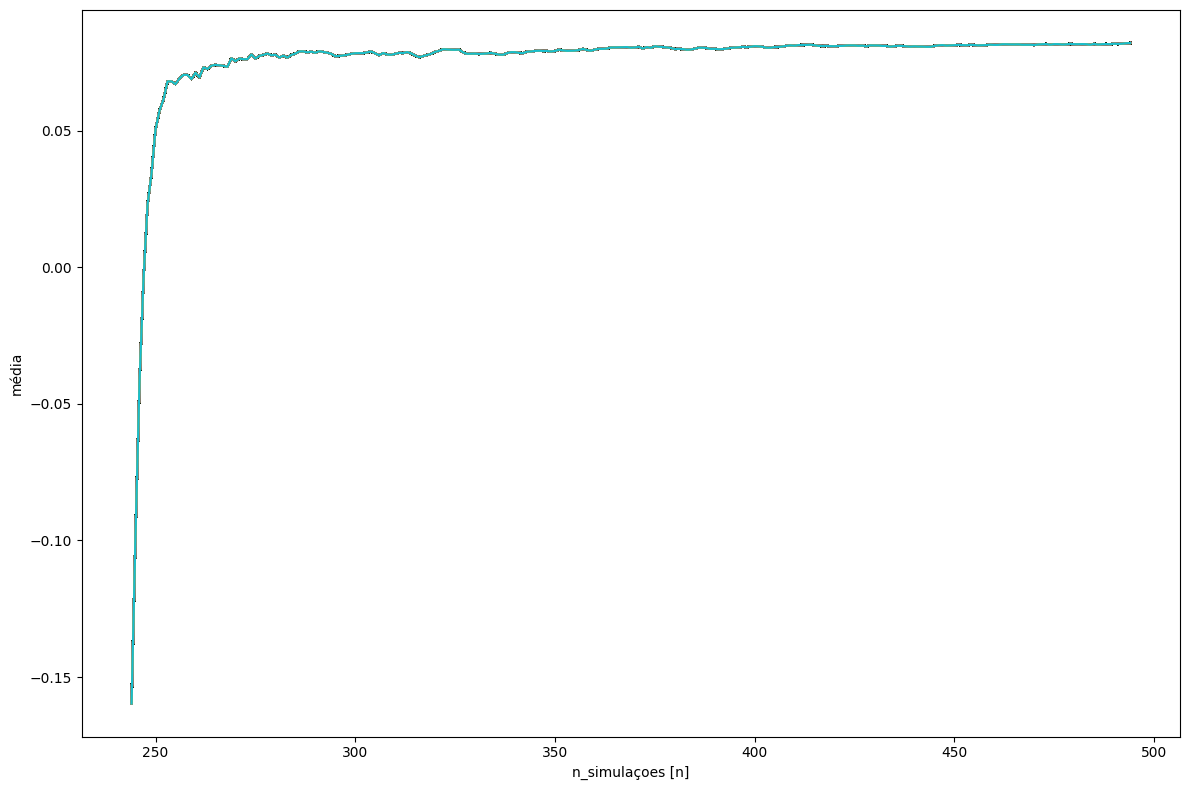

In [47]:
mean_ibc_high = []
plt.figure(figsize=(12,8))
for i in range(sim):
    ibc_ = MonteCarlo(X_mc).sim_scenario(scenarios, 10, 'IBC-Br')
    beta_ = MonteCarlo(X_mc).sim_scenario(scenarios, 0, 'BETA')
    df_ibc_high = pd.concat([ibc_, beta_], axis=1)
    pred_ibc_high = new_ardl.predict(start=len(y_train), end=len(y_train)+len(df_ibc_high)-1, exog_oos=df_ibc_high)
    y_hat_ = np.cumsum(pred_ibc_high)/np.arange(len(pred_ibc_high))
    mean_ibc_high.append(pred_ibc_high)
    plt.plot(y_hat)
plt.xlabel('n_simulaçoes [n]')
plt.ylabel('média')
plt.tight_layout()
plt.show()

In [48]:
# diagnosticos 
mean_ibc_high = np.array(mean_ibc_high)
print('===='*20)
print(f'--- Diagnostico - Cenario de IBC em crescimento--- ')
print('===='*20)

print(f'valor médio das previsoes: {round(mean_ibc_high.mean(), 2)} <--')
print(f'Valor minimo -> {mean_ibc_high.min()}')
print(f'Valor maximo -> {mean_ibc_high.max()}')
print(f'desvio: {round(mean_ibc_high.std(),2)} <--')
print('===='*20)

print(f'50% da volatilidade nesse cenario é maior que {round(np.median(mean_ibc_high),3)}')
print()
print(f'25% da volatilidade nesse cenario é maior que {round(np.percentile(mean_ibc_high,75),2)}')
print()
print(f'10% da volatilidade nesse cenario é maior que {round(np.percentile(mean_ibc_high, 90),2)}')
print()
print(f'5% da volatilidade nesse cenario é maior que {round(np.percentile(mean_ibc_high, 95),2)}')
print('===='*20)





--- Diagnostico - Cenario de IBC em crescimento--- 
valor médio das previsoes: 0.08 <--
Valor minimo -> -0.2263921686118023
Valor maximo -> 0.24280153630121326
desvio: 0.04 <--
50% da volatilidade nesse cenario é maior que 0.083

25% da volatilidade nesse cenario é maior que 0.1

10% da volatilidade nesse cenario é maior que 0.12

5% da volatilidade nesse cenario é maior que 0.14


IBC-Br normal + BETA em crescente 

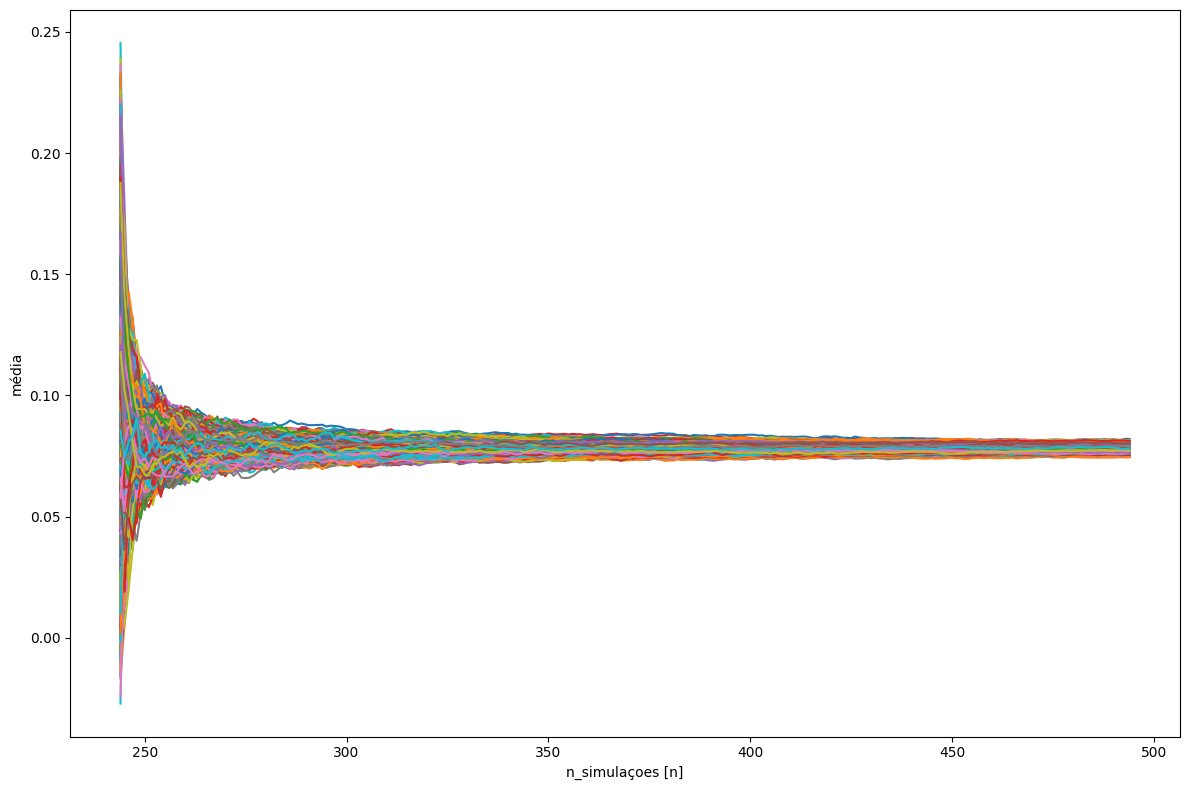

In [49]:
beta_high_mean = []
plt.figure(figsize=(12,8))
for i in range(sim):
    beta_high = MonteCarlo(X_mc).sim_scenario(scenarios, 10, 'BETA')
    ibc = MonteCarlo(X_mc).sim_scenario(scenarios, 0, 'IBC-Br')
    df_beta_high = pd.concat([ibc, beta_high], axis=1)
    pred_beta_high = new_ardl.predict(start=len(y_train), end=len(y_train)+len(df_beta_high)-1, exog_oos=df_beta_high)
    y_hat = np.cumsum(pred_beta_high)/np.arange(len(pred_beta_high))
    beta_high_mean.append(pred_beta_high)
    
    plt.plot(y_hat)
plt.xlabel('n_simulaçoes [n]')
plt.ylabel('média')
plt.tight_layout()
plt.show()

In [50]:
beta_high_mean = np.array(beta_high_mean)
print('===='*20)
print(f'--- Diagnostico - Cenario de BETA em crescimento --- ')
print('===='*20)
print()
print(f'valor médio das previsoes: {round(beta_high_mean.mean(), 2)} <--')
print()
print(f'Valor minimo -> {beta_high_mean.min()}')
print(f'Valor maximo -> {beta_high_mean.max()}')
print()
print(f'desvio: {round(beta_high_mean.std(),2)} <--')

print('===='*20)

print(f'50% da volatilidade nesse cenario é maior que {round(np.median(beta_high_mean),3)}')
print(f'25% da volatilidade nesse cenario é maior que {round(np.percentile(beta_high_mean,75),2)}')
print(f'10% da volatilidade nesse cenario é maior que {round(np.percentile(beta_high_mean, 90),2)}')
print(f'5% da volatilidade nesse cenario é maior que {round(np.percentile(beta_high_mean, 95),2)}')
print('===='*20)


--- Diagnostico - Cenario de BETA em crescimento --- 

valor médio das previsoes: 0.08 <--

Valor minimo -> -0.08114895051758915
Valor maximo -> 0.24789641765839587

desvio: 0.03 <--
50% da volatilidade nesse cenario é maior que 0.078
25% da volatilidade nesse cenario é maior que 0.1
10% da volatilidade nesse cenario é maior que 0.12
5% da volatilidade nesse cenario é maior que 0.13


IBC-Br em queda + BETA em crescimento 

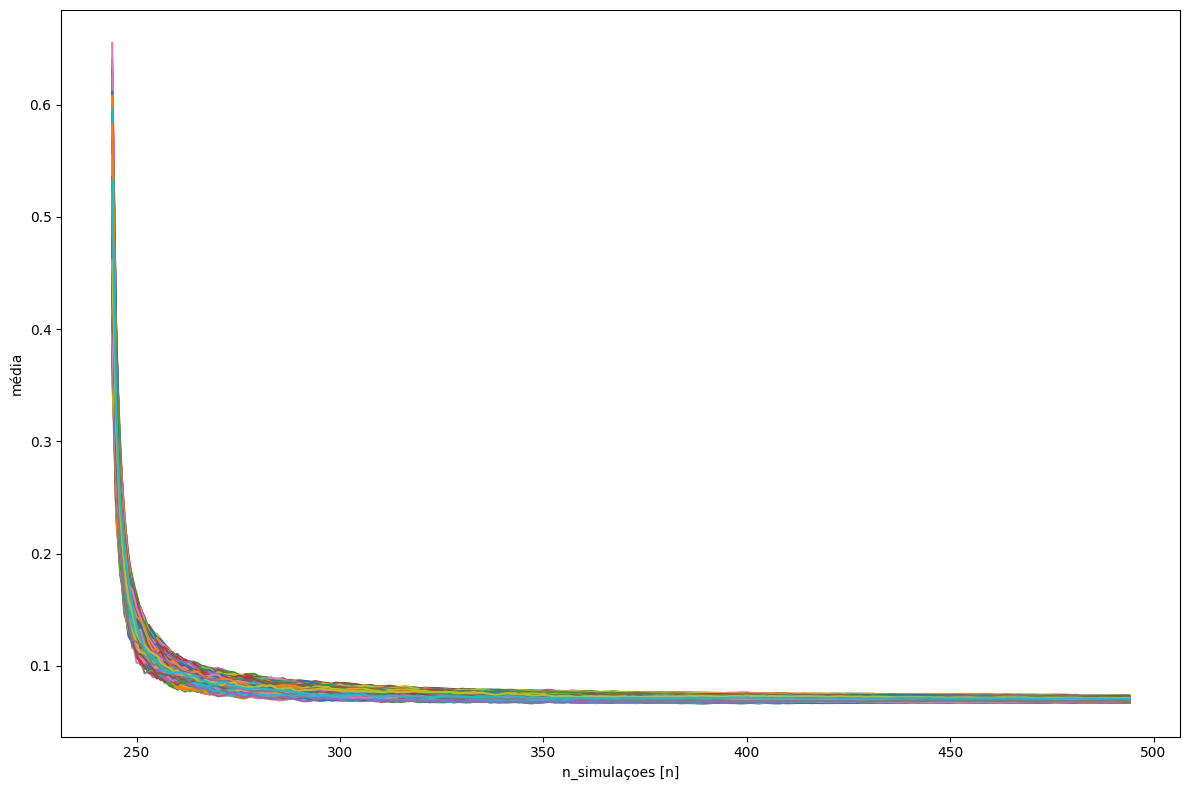

In [51]:
mean_ibc_low_beta_high = []
df_plot = []
plt.figure(figsize=(12,8))
for _ in range(sim):
    ibc_low = MonteCarlo(X_mc).sim_scenario(scenarios, -15, 'IBC-Br') # apliquei 15% de queda 
    beta_high_ = MonteCarlo(X_mc).sim_scenario(scenarios, 10, 'BETA')
    df_sim = pd.concat([ibc_low, beta_high_], axis=1)
    pred_sim_ibc_low = new_ardl.predict(start=len(y_train), end=len(y_train)+len(df_sim)-1, exog_oos=df_sim)
    y_hat = np.cumsum(pred_sim_ibc_low)/np.arange(len(pred_sim_ibc_low))
    mean_ibc_low_beta_high.append(pred_sim_ibc_low)
    df_plot.append(df_sim)
    
    plt.plot(y_hat)
plt.xlabel('n_simulaçoes [n]')
plt.ylabel('média')
plt.tight_layout()
plt.show()

In [52]:
mean_ibc_low_beta_high = np.array(mean_ibc_low_beta_high)
print('===='*20)
print(f'--- Diagnostico - Cenario de BETA em crescimento + IBC-Br em queda --- ')
print('===='*20)

print()
print(f'valor médio das previsoes: {round(mean_ibc_low_beta_high.mean(), 2)} <--')
print()
print(f'Valor minimo -> {mean_ibc_low_beta_high.min()}')
print(f'Valor maximo -> {mean_ibc_low_beta_high.max()}')
print()
print(f'desvio: {round(mean_ibc_low_beta_high.std(),2)} <--')

print('===='*20)
print(f'50% da volatilidade nesse cenario é maior que {round(np.median(mean_ibc_low_beta_high),3)}')
print(f'25% da volatilidade nesse cenario é maior que {round(np.percentile(mean_ibc_low_beta_high,75),2)}')
print(f'10% da volatilidade nesse cenario é maior que {round(np.percentile(mean_ibc_low_beta_high, 90),2)}')
print(f'5% da volatilidade nesse cenario é maior que {round(np.percentile(mean_ibc_low_beta_high, 95),2)}')
print('===='*20)


--- Diagnostico - Cenario de BETA em crescimento + IBC-Br em queda --- 

valor médio das previsoes: 0.07 <--

Valor minimo -> -0.08946089880249478
Valor maximo -> 0.4180760245467113

desvio: 0.04 <--
50% da volatilidade nesse cenario é maior que 0.069
25% da volatilidade nesse cenario é maior que 0.09
10% da volatilidade nesse cenario é maior que 0.11
5% da volatilidade nesse cenario é maior que 0.12


Mesmo aumentando o BETA em nossas simulações, não observamos explosão no sigma (volatidade). Isso se deve por N fatores: 

- Como o IBC-Br mede o quão aquecido esta a economia no macro, ele tende a criar uma "área" de retraçao ou de expansão. 

- Baixo IBC-Br -> Mercado mais recioso -> Menos volume -> Área diminui -> volatidade controlada 

 **Mesmo com o BETA em crescente, o IBC-Br tende a frear a crescente da volatidade, fazendo assim a propagação da ser reduzida**

 Sabendo que meu BETA é calculado pela razão entre a COV(PETR4, IBOV) e VAR(IBOV), só confirma que o crescimento do BETA pode ser freado pelo ambiente macroeconmico, impedindo que isso se traduza em expansão da volatilidade. 

 Fazendo assim, nossa função resposta ter essa cara: 

 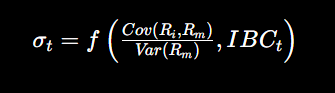

Sendo o IBC-Br um "amortecedor" econômico, podemos enxergar em nossos diagnosticos um valor max de 0.41, mas um desvio de 0.04, que é relativamente baixo, com as outras distribuiçoes e percentis proximos a si mesmos. Confirmando assim, o efeito do IBC-Br

In [53]:
mean_ibc_low_beta_high[0]

array([ 0.31358131,  0.19426031,  0.12994232,  0.00324144,  0.07814348,
        0.02098629,  0.10275309,  0.0788088 ,  0.07790826,  0.04472137,
        0.05520843,  0.01900723,  0.04333235,  0.07407735,  0.0916099 ,
        0.10663875,  0.0599866 ,  0.05003386,  0.06850326,  0.07146931,
        0.07415109,  0.08951659,  0.01649639,  0.0681259 ,  0.09195121,
        0.10272625,  0.00809545,  0.11458319,  0.10590933,  0.00560243,
        0.07652601,  0.02351331,  0.0490534 ,  0.04501892,  0.1034625 ,
        0.06032128,  0.12484135,  0.00543729,  0.07237649,  0.03419192,
        0.08117609,  0.00312344,  0.0704546 ,  0.07922709,  0.13670834,
        0.08709813,  0.09868488,  0.03733654,  0.0396286 ,  0.07154946,
        0.07199607,  0.06075853,  0.07262537,  0.07674061,  0.03040753,
        0.09140381,  0.03387248,  0.08932373,  0.08342009,  0.09195765,
        0.0266865 ,  0.0181129 ,  0.055179  ,  0.09879256,  0.0830493 ,
        0.0493406 ,  0.06398873,  0.0270003 ,  0.08414023,  0.05

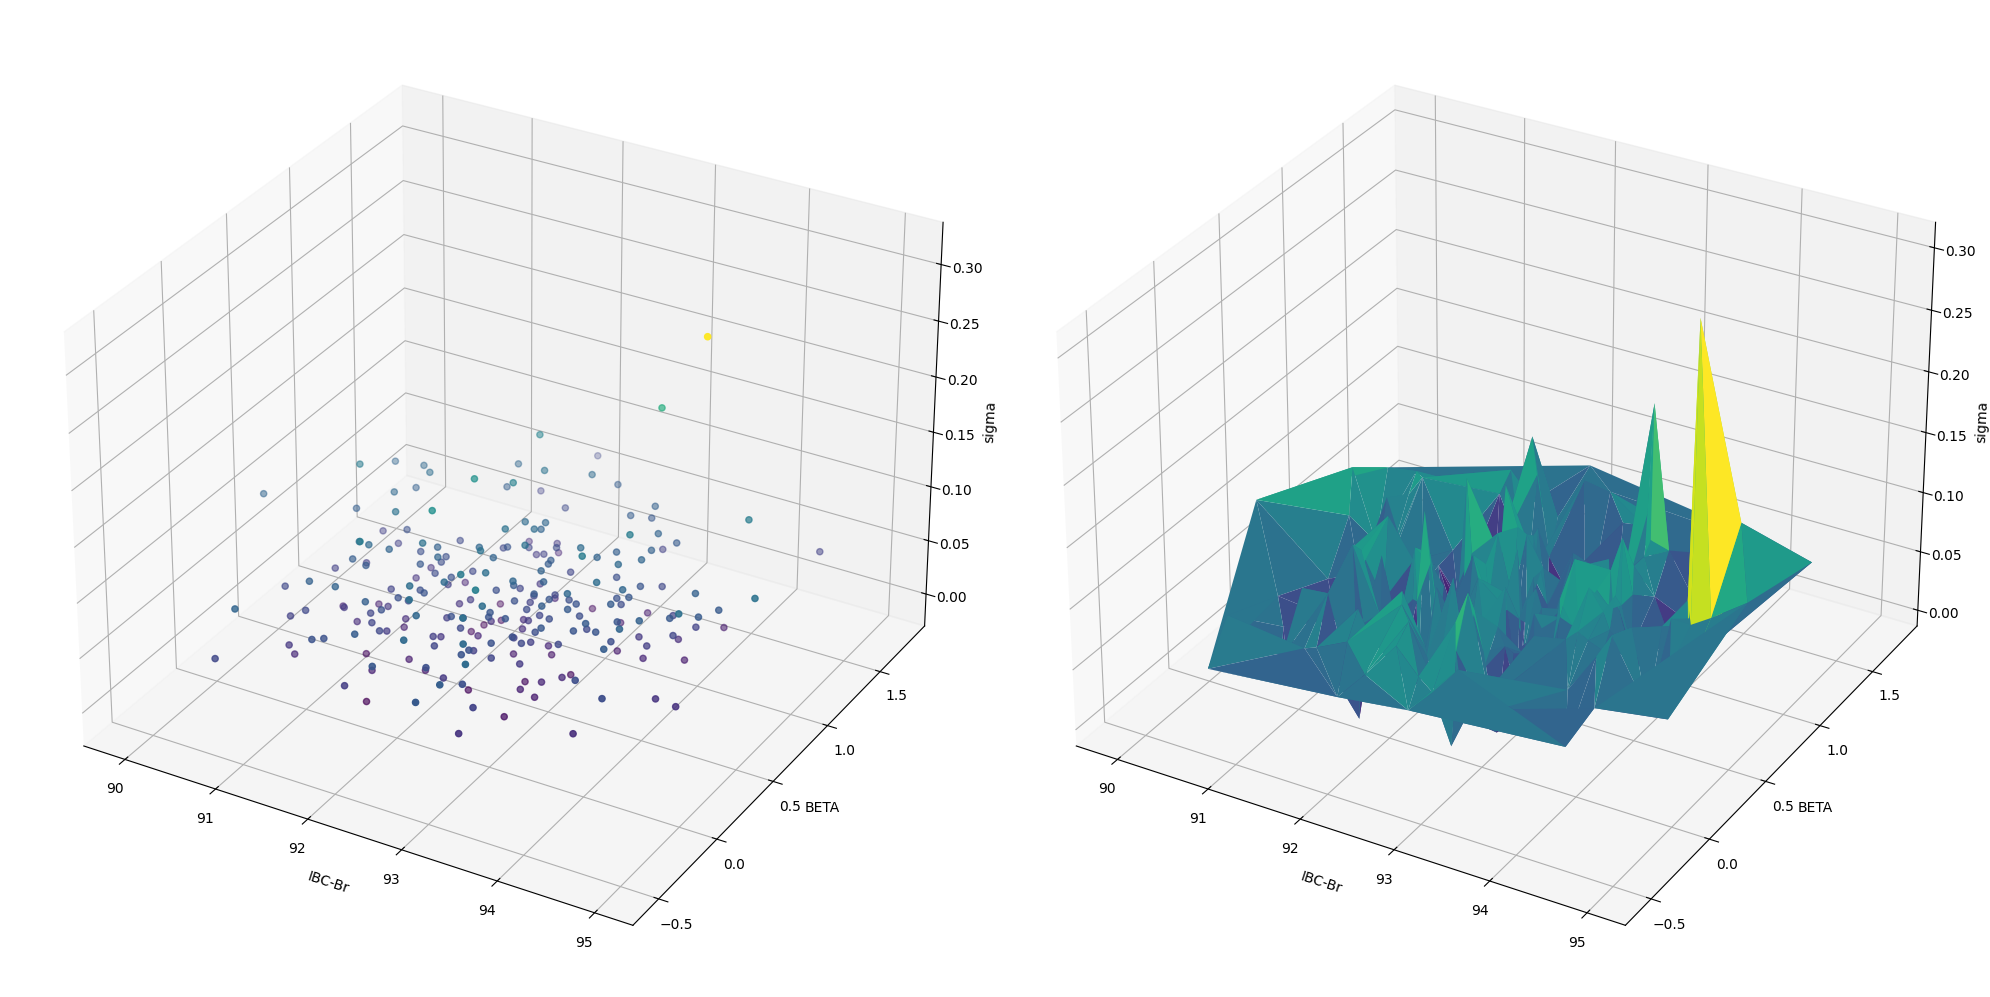

In [54]:
# plotando area de estudo 
X_plot = df_sim['IBC-Br']
y_plot = df_sim['BETA']
Z = mean_ibc_low_beta_high[0]
fig_plot = plt.figure(figsize=(20,20))

ax = fig_plot.add_subplot(1,2,1, projection='3d')
ax.scatter(X_plot,y_plot, Z, c=Z)
ax.set_xlabel('IBC-Br')
ax.set_ylabel('BETA')
ax.set_zlabel('sigma')

ax2 = fig_plot.add_subplot(1,2,2, projection='3d')
ax2.plot_trisurf(X_plot, y_plot, Z, cmap='viridis')
ax2.set_xlabel('IBC-Br')
ax2.set_ylabel('BETA')
ax2.set_zlabel('sigma')

plt.tight_layout()
plt.show()

Podemos observar uma area definida, com pontos poucos dispersos (salvo 1 outlier dado simulaçao)

# Metricas 

In [55]:
def sknew_kurtosis(distribuition:pd.Series):
    n = len(distribuition)
    mu = distribuition.mean()
    std = distribuition.std()
    
    #calculando sknew 
    part1 = (n)/(n-1)*(n-2)
    part2 = ((np.sum(distribuition-mu))/std)**3
    
    #calculando kurtosis
    kurtosis = (((np.sum(distribuition - mu)/std)**4)-3)/n
    return part1*part2, kurtosis
    

Avaliaçao de niveis de riscos - MonteCarlo
média do sigma original: 0.08238528653380751

média sigma - simulaçao subida mútua -> 0.0822
média sigma - simulaçao IBC-BR em crescimento -> 0.0815
média sigma - simulaçao BETA em crescimento -> 0.07777 
média sigma - IBC-Br em queda + BETA em crescimento -> 0.07008 

[VARIANCIA]
variancia sigma ORIGINAL -> 0.001511944644302258
variancia sigma - simulaçao subida mútua -> 0.00135
variancia sigma - simulaçao IBC-BR em crescimento -> 0.0013
variancia sigma - simulaçao BETA em crescimento -> 0.00108 
variancia sigma - IBC-Br em queda + BETA em crescimento -> 0.00127 
[PERCENTIS]
percentis sigma ORIGINAL -> 0.14520603847310923
percentis sigma - simulaçao subida mútua -> 0.13858888313467083
percentis sigma - simulaçao IBC-BR em crescimento -> 0.13654515001065956
percentis sigma - simulaçao BETA em crescimento -> 0.13190142296196292 
percentis sigma - IBC-Br em queda + BETA em crescimento -> 0.1227508444380349 
[DRAWDOWN]
simulaçao subida_mutua -> d

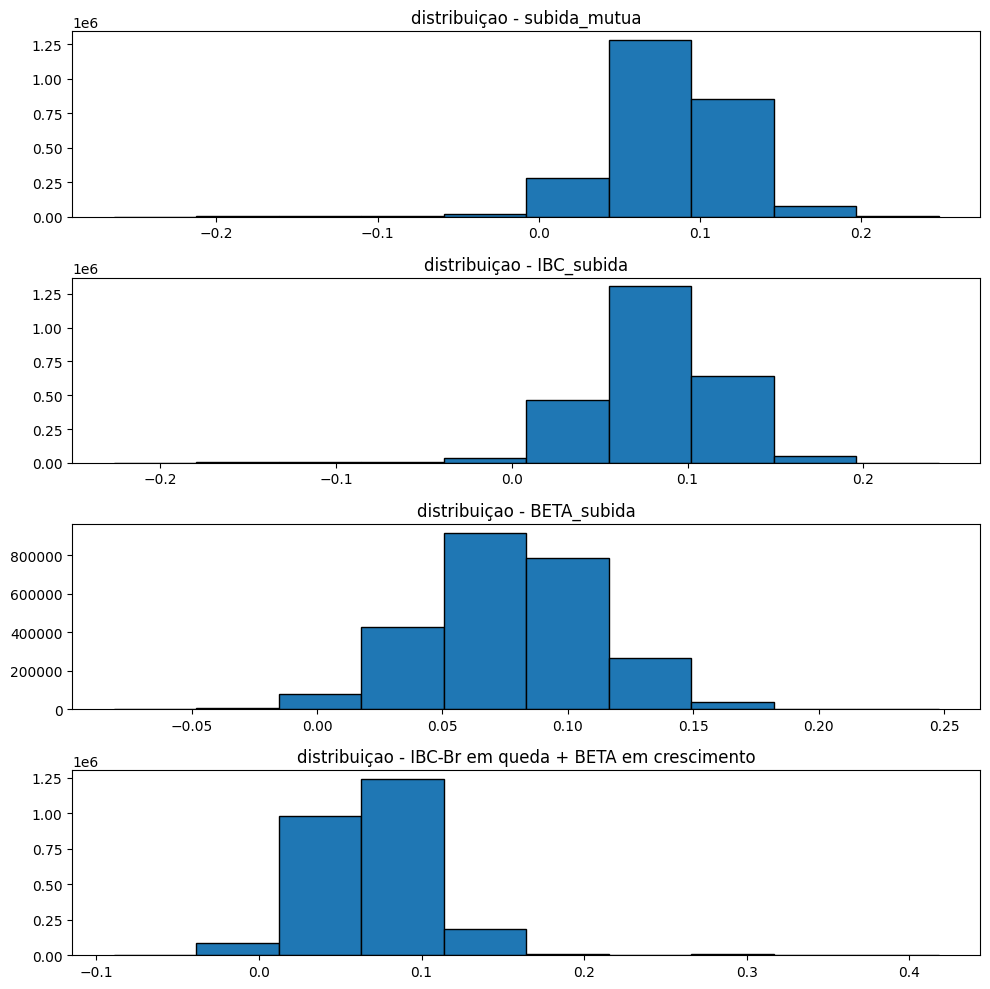

In [56]:
print("==="*20)
print('Avaliaçao de niveis de riscos - MonteCarlo')
print("==="*20)
print(f"média do sigma original: {y_test.mean()}")
print()
print(f'média sigma - simulaçao subida mútua -> {round(mean_high.mean(),5)}')
print(f'média sigma - simulaçao IBC-BR em crescimento -> {round(mean_ibc_high.mean(),5)}')
print(f'média sigma - simulaçao BETA em crescimento -> {round(beta_high_mean.mean(),5)} ')
print(f'média sigma - IBC-Br em queda + BETA em crescimento -> {round(mean_ibc_low_beta_high.mean(),5)} ')
print()
print("==="*20)
print('[VARIANCIA]')
print("==="*20)
print(f'variancia sigma ORIGINAL -> {y_test.var()}')
print(f'variancia sigma - simulaçao subida mútua -> {round(mean_high.var(),5)}')
print(f'variancia sigma - simulaçao IBC-BR em crescimento -> {round(mean_ibc_high.var(),5)}')
print(f'variancia sigma - simulaçao BETA em crescimento -> {round(beta_high_mean.var(),5)} ')
print(f'variancia sigma - IBC-Br em queda + BETA em crescimento -> {round(mean_ibc_low_beta_high.var(),5)} ')
print("==="*20)
print('[PERCENTIS]')
print("==="*20)

print(f"percentis sigma ORIGINAL -> {np.percentile(y_test,95)}")
print(f'percentis sigma - simulaçao subida mútua -> {np.percentile(mean_high,95)}')
print(f'percentis sigma - simulaçao IBC-BR em crescimento -> {np.percentile(mean_ibc_high,95)}')
print(f'percentis sigma - simulaçao BETA em crescimento -> {np.percentile(beta_high_mean,95)} ')
print(f'percentis sigma - IBC-Br em queda + BETA em crescimento -> {np.percentile(mean_ibc_low_beta_high,95)} ')
print("==="*20)
print('[DRAWDOWN]')
dd = {'subida_mutua':mean_high, 
    'IBC_subida':mean_ibc_high,
    'BETA_subida':beta_high_mean, 
    'IBC-Br em queda + BETA em crescimento':mean_ibc_low_beta_high}

fig, axes = plt.subplots(len(dd), 1, figsize=(10,10))
for ax, (name, num) in zip( axes, dd.items()):
    data = pd.Series(num.flatten())
    data_abs = np.abs(data)
    data_abs = data_abs.clip(lower=0.01)
    max_price = data_abs.cummax()
    
    #calculando delta de variaçao 
    zscore_sigma = (data-data.mean())/data.std()
    drawdown = (data_abs/max_price)-1    
    print(f'simulaçao {name} -> drawdown:{drawdown.min()}')
    print(f'ZSCORE(min) -> {zscore_sigma.min()} | ZSCORE(max) -> {zscore_sigma.max()} ')
    print()
    ax.hist(data, edgecolor='black')
    ax.set_title(f'distribuiçao - {name}')
plt.tight_layout()
plt.show()

In [57]:
# calculando knew 
for i, num in dd.items(): 
    print(f'{i} - skenew -> {sknew_kurtosis(num)[0]} | kurtosis -> {sknew_kurtosis(num)[1]}')

subida_mutua - skenew -> -2.6785032775391348e-25 | kurtosis -> -0.0003
IBC_subida - skenew -> -9.053475946132024e-26 | kurtosis -> -0.0003
BETA_subida - skenew -> -2.397153102971807e-29 | kurtosis -> -0.0003
IBC-Br em queda + BETA em crescimento - skenew -> -1.1223422791038225e-26 | kurtosis -> -0.0003


# Gerando Simulações com distribuições t_student

Nas outras simulações, estavamos trabalhando com distruibuições puramentes normais, sem caudas longas e sem muita variação entre elas. Agora, meu intuito é utilizar a distruibuição t_student dado amostras para gerar novas simulções com menos incerteza e mais variabilidade. 

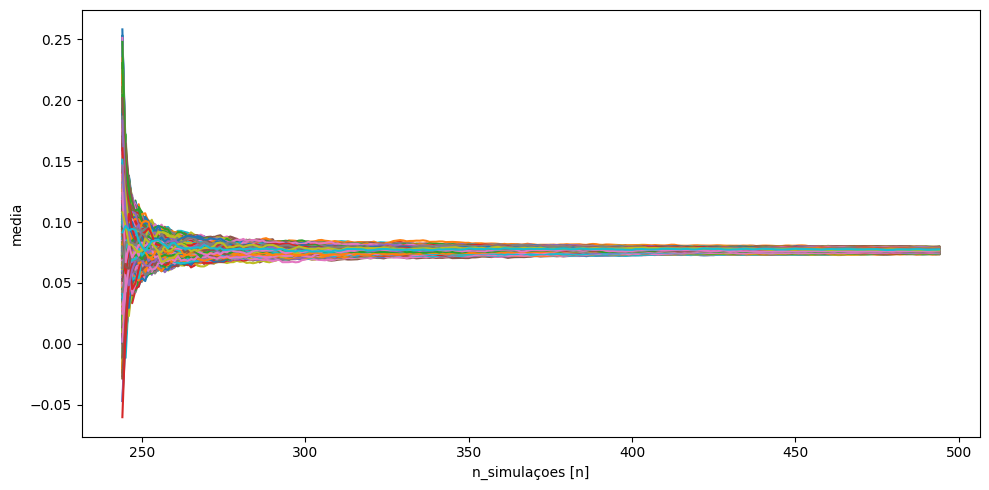

In [58]:
# cenarios sem nenhum choque
t_results = []
df_plot_t = []
plt.figure(figsize=(10,5))
for _ in range(sim):
    ibc_t = MonteCarlo(X_mc).T_student_sim(scenarios, 'IBC-Br')
    beta_t = MonteCarlo(X_mc).T_student_sim(scenarios, 'BETA')
    df_t = pd.concat([ibc_t, beta_t], axis=1)
    pred_t = new_ardl.predict(start=len(y_train), end=len(y_train)+len(df_t)-1, exog_oos=df_t)
    t_hat = np.cumsum(pred_t)/np.arange(len(pred_t))
    t_results.append(pred_t)
    df_plot_t.append(df_t)
    plt.plot(t_hat)
plt.xlabel('n_simulaçoes [n]')
plt.ylabel('media')
plt.tight_layout()
plt.show()
    

In [59]:
t_results = np.array(t_results)
print('===='*20)
print(f'--- Diagnostico - Distribuição t_student - VARIAVEIS SEM CHOQUE --- ')
print('===='*20)

print()
print(f'valor médio das previsoes: {round(t_results.mean(), 2)} <--')
print()
print(f'Valor minimo -> {t_results.min()}')
print(f'Valor maximo -> {t_results.max()}')
print()
print(f'desvio: {round(t_results.std(),2)} <--')

print('===='*20)
print(f'50% da volatilidade nesse cenario é maior que {round(np.median(t_results),3)}')
print(f'25% da volatilidade nesse cenario é maior que {round(np.percentile(t_results,75),3)}')
print(f'10% da volatilidade nesse cenario é maior que {round(np.percentile(t_results, 90),2)}')
print(f'5% da volatilidade nesse cenario é maior que {round(np.percentile(t_results, 95),2)}')
print('===='*20)
print(f'skenew: {sknew_kurtosis(t_results)[0]} kurtosis: {sknew_kurtosis(t_results)[1]}')

--- Diagnostico - Distribuição t_student - VARIAVEIS SEM CHOQUE --- 

valor médio das previsoes: 0.08 <--

Valor minimo -> -0.1035664117835385
Valor maximo -> 0.26976155393770757

desvio: 0.03 <--
50% da volatilidade nesse cenario é maior que 0.076
25% da volatilidade nesse cenario é maior que 0.098
10% da volatilidade nesse cenario é maior que 0.12
5% da volatilidade nesse cenario é maior que 0.13
skenew: 2.3755231177820074e-25 kurtosis: -0.0003


In [60]:
df_plot_t = df_plot_t[0]

In [61]:
type(df_plot_t)

pandas.core.frame.DataFrame

In [62]:
# função para plot de area
def plot_surface(x:pd.Series, y:pd.Series, z:pd.Series, title:str):
    x_data = np.array(x)
    y_data = np.array(y)
    z_data = np.array(z)
    #criando grid para plot 
    X, Y = np.meshgrid(np.linspace(x_data.min(), x_data.max(), 50),
                        np.linspace(y_data.min(), y_data.max(), 50))
    Z = griddata((x_data, y_data), z_data, (X, Y), method='linear')
    
    fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'surface'}, {'type': 'scene'}]])    
    fig.add_trace(go.Surface(x=X, y=Y, z=Z), row=1,col=1)
    fig.update_traces(contours_z=dict(show=True, usecolormap=True, highlightcolor="limegreen", project_z=True))
    fig.update_layout(title=title,autosize=False,width=1400,height=700, margin=dict(l=65, r=50, b=65, t=90))
    
    fig.add_trace(go.Scatter3d(x=x_data,y=y_data,z=z_data,mode='markers',marker=dict(size=4)),row=1,col=2)    
    fig.update_scenes(xaxis_title=x.name,yaxis_title=y.name,zaxis_title=z.name,camera_eye=dict(x=1.87, y=0.88, z=-0.64),row=1,col=1)
    fig.update_scenes(xaxis_title=x.name,yaxis_title=y.name,zaxis_title=z.name,camera_eye=dict(x=1.87, y=0.88, z=-0.64),row=1,col=2)

    fig.show()

In [64]:
# plotando simulações em t sem choque 
plot_surface(df_plot_t['IBC-Br'], df_plot_t['BETA'],t_results[0], 'Simulações T-Student' )

NameError: name 'make_subplots' is not defined

Como esperado, os resultados das simulações com t_student foram parecidas com o cenario normal. As estatisticas mostram um controle entre as caudas dos dados, com médias e percentis flutuando como os dados anteriores. Agora, basta aplicar alguns choques para verificar novos resultados em novas distribuições.

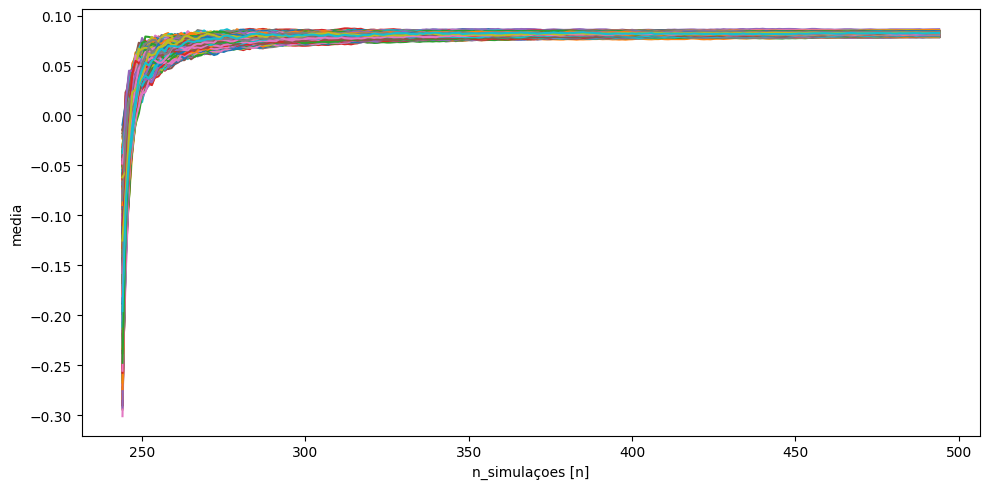

In [ ]:
ibc_t_list = []
df_ibc_t = []
plt.figure(figsize=(10,5))
for _ in range(sim):
    ibc_t_high = MonteCarlo(X_mc).T_student_shocks(scenarios, 10, 'IBC-Br')
    beta_t_normal = MonteCarlo(X_mc).T_student_sim(scenarios, 'BETA')
    df_t_ibc = pd.concat([ibc_t_high, beta_t_normal], axis=1)
    pred_t_ibc = new_ardl.predict(start=len(y_train), end=len(y_train)+len(df_t_ibc)-1, exog_oos=df_t_ibc)
    y_hat_ibc = np.cumsum(pred_t_ibc)/np.arange(len(pred_t_ibc))
    ibc_t_list.append(pred_t_ibc)
    df_ibc_t.append(df_t_ibc)
    plt.plot(y_hat_ibc)
plt.xlabel('n_simulaçoes [n]')
plt.ylabel('media')
plt.tight_layout()
plt.show()
    

In [ ]:
ibc_t_list= np.array(ibc_t_list)
print('===='*20)
print(f'--- Diagnostico - Distribuição t_student - IBC-BR em crescente --- ')
print('===='*20)

print()
print(f'valor médio das previsoes: {round(ibc_t_list.mean(), 2)} <--')
print()
print(f'Valor minimo -> {ibc_t_list.min()}')
print(f'Valor maximo -> {ibc_t_list.max()}')
print()
print(f'desvio: {round(ibc_t_list.std(),2)} <--')

print('===='*20)
print(f'50% da volatilidade nesse cenario é maior que {round(np.median(ibc_t_list),3)}')
print(f'25% da volatilidade nesse cenario é maior que {round(np.percentile(ibc_t_list,75),3)}')
print(f'10% da volatilidade nesse cenario é maior que {round(np.percentile(ibc_t_list, 90),2)}')
print(f'5% da volatilidade nesse cenario é maior que {round(np.percentile(ibc_t_list, 95),2)}')
print('===='*20)
print(f'skenew: {sknew_kurtosis(ibc_t_list)[0]} kurtosis: {sknew_kurtosis(ibc_t_list)[1]}')

--- Diagnostico - Distribuição t_student - IBC-BR em crescente --- 

valor médio das previsoes: 0.08 <--

Valor minimo -> -0.2478885773972709
Valor maximo -> 0.2855265926983216

desvio: 0.04 <--
50% da volatilidade nesse cenario é maior que 0.083
25% da volatilidade nesse cenario é maior que 0.106
10% da volatilidade nesse cenario é maior que 0.13
5% da volatilidade nesse cenario é maior que 0.14
skenew: -3.1945007227823798e-25 kurtosis: -0.0003


In [ ]:
df_ibc_t = df_ibc_t[0]

In [ ]:
# plotando simulações t student com choque no ibc-br 
plot_surface(df_ibc_t['IBC-Br'], df_ibc_t['BETA'], ibc_t_list[0], 'simulações T-student -> choque no IBC-Br')

Claramente a area da superficie mudou dado subida do ibc-br, fazendo assim a volatilidade variar

**Simulação IBC-Br em queda -> continuidade do BETA**

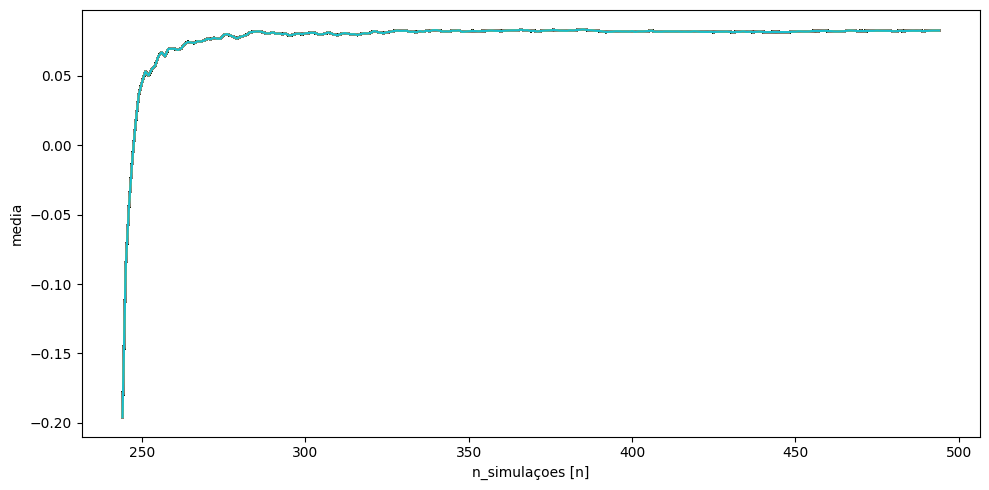

In [ ]:
ibclow_t_list = []
df_ibclow_t = []
plt.figure(figsize=(10,5))
for _ in range(sim):
    ibc_t_low = MonteCarlo(X_mc).T_student_shocks(scenarios, -10, 'IBC-Br')
    beta_t_normal = MonteCarlo(X_mc).T_student_sim(scenarios, 'BETA')
    df_t_ibclow = pd.concat([ibc_t_high, beta_t_normal], axis=1)
    pred_t_ibclow = new_ardl.predict(start=len(y_train), end=len(y_train)+len(df_t_ibclow)-1, exog_oos=df_t_ibclow)
    y_hat_ibclow = np.cumsum(pred_t_ibc)/np.arange(len(pred_t_ibc))
    ibclow_t_list.append(pred_t_ibclow)
    df_ibclow_t.append(df_t_ibclow)
    plt.plot(y_hat_ibclow)
plt.xlabel('n_simulaçoes [n]')
plt.ylabel('media')
plt.tight_layout()
plt.show()

In [ ]:
ibclow_t_list= np.array(ibclow_t_list)
df_ibclow_t = df_ibclow_t[0]
print('===='*20)
print(f'--- Diagnostico - Distribuição t_student - IBC-BR em decrescente --- ')
print('===='*20)

print()
print(f'valor médio das previsoes: {round(ibclow_t_list.mean(), 2)} <--')
print()
print(f'Valor minimo -> {ibclow_t_list.min()}')
print(f'Valor maximo -> {ibclow_t_list.max()}')
print()
print(f'desvio: {round(ibclow_t_list.std(),2)} <--')

print('===='*20)
print(f'50% da volatilidade nesse cenario é maior que {round(np.median(ibclow_t_list),3)}')
print(f'25% da volatilidade nesse cenario é maior que {round(np.percentile(ibclow_t_list,75),3)}')
print(f'10% da volatilidade nesse cenario é maior que {round(np.percentile(ibclow_t_list, 90),2)}')
print(f'5% da volatilidade nesse cenario é maior que {round(np.percentile(ibclow_t_list, 95),2)}')
print('===='*20)
print(f'skenew: {sknew_kurtosis(ibclow_t_list)[0]} kurtosis: {sknew_kurtosis(ibclow_t_list)[1]}')

--- Diagnostico - Distribuição t_student - IBC-BR em decrescente --- 

valor médio das previsoes: 0.08 <--

Valor minimo -> -0.24022528453889203
Valor maximo -> 0.2543012515277572

desvio: 0.04 <--
50% da volatilidade nesse cenario é maior que 0.083
25% da volatilidade nesse cenario é maior que 0.106
10% da volatilidade nesse cenario é maior que 0.13
5% da volatilidade nesse cenario é maior que 0.14
skenew: -1.4712394721745864e-24 kurtosis: -0.0003


In [ ]:
plot_surface(df_ibclow_t['IBC-Br'], df_ibclow_t['BETA'], ibclow_t_list[0], 'IBC-Br em queda')

In [ ]:
np.percentile(ibclow_t_list[0], 70)

np.float64(0.09883253183669448)

In [ ]:
# criando funcoes para separaçao de bandas de risco 
def risk_proba(vol_sim:np.array, bands:list):
    risk_bands =bands
    print('===='*10)
    data_band_list = []
    for i in risk_bands:
        if i > 100:
            print('digite bandas validas')
            break
        limiar = np.percentile(vol_sim, i)
        print(f'banda -> {i}%: {limiar}')
        data_bands = pd.DataFrame()

        risks = np.where(vol_sim>np.percentile(vol_sim, i),1,0)
        data_bands[f'limiar_{i}'] = risks 
        data_bands = pd.DataFrame(data_bands)
        data_band_list.append(data_bands)
    
    return pd.concat(data_band_list, axis=1)

Calculando bandas de risco sobre o sigma de 2024 a 2026

In [ ]:
risk_bands = risk_proba(y_test, [50, 75, 90])
risk_bands.mean()

banda -> 50%: 0.07091238068716131
banda -> 75%: 0.10611770636605954
banda -> 90%: 0.1371608542294537


limiar_50    0.476190
limiar_75    0.238095
limiar_90    0.095238
dtype: float64

Trabalhando separaçoes de risco sobre as simulaçoes

In [ ]:
sim_dict = {
    'sim_normal':pred_mc_normal, 
    'ibc_low':pred_ibc_low,
    'ibc-high':mean_ibc_high,
    'beta-high':beta_high_mean,
    'ibc_low_beta_high':mean_ibc_low_beta_high,
    'sim_t_normal':t_results,
    'ibc_t':ibc_t_list,
    'ibc_low_t':ibclow_t_list
    
}
print('==='*20)
print('Probabilidade de risco de banda das simulaçoes')
print('==='*20)
limiar90 = 0.095238
for i, sim in sim_dict.items():
    risk_prob = np.mean((sim>limiar90))
    print(f'{i}:{round(risk_prob,2)*100}%')
    print()
print('==='*20)


Probabilidade de risco de banda das simulaçoes
sim_normal:28.000000000000004%

ibc_low:25.0%

ibc-high:35.0%

beta-high:30.0%

ibc_low_beta_high:20.0%

sim_t_normal:28.000000000000004%

ibc_t:36.0%

ibc_low_t:36.0%



In [69]:
X_mc.shape

(21, 2)

In [95]:
ibc_fore = np.repeat(X_mc['IBC-Br'], 100)
ibc_fore = pd.Series(ibc_fore, name='IBC-Br')
beta_fore = np.repeat(X_mc['BETA'], 100,)
beta_fore = pd.Series(beta_fore, name='BETA')
fore_df = pd.concat([ibc_fore, beta_fore], axis=1)
#fore_df = fore_df.reset_index(drop=True)
fore_df = fore_df.sample(len(fore_df))
fore_df 

,IBC-Br,BETA
data,,
2025-05-01,109.03852,0.563835
2025-07-01,108.39056,0.310455
2025-05-01,109.03852,0.563835
2024-07-01,106.92867,0.071381
2025-08-01,108.82974,-0.015980
...,...,...
2024-09-01,108.03396,0.247604
2024-07-01,106.92867,0.071381
2025-04-01,110.45243,0.600945


<Axes: >

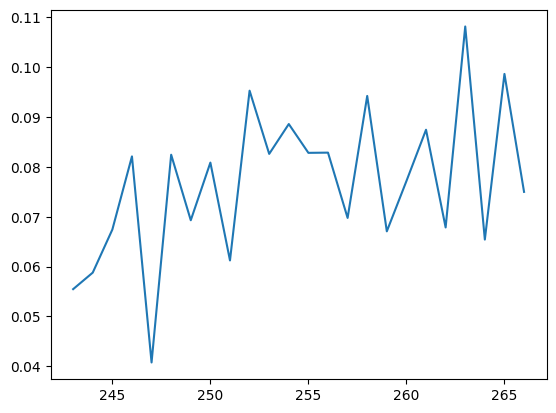

In [98]:
new_ardl.forecast(24, fore_df).plot()

In [94]:
pd.date_range(start='2026-03-01', periods=3, freq='M')

DatetimeIndex(['2026-03-31', '2026-04-30', '2026-05-31'], dtype='datetime64[ns]', freq='ME')

In [102]:
X_mc['IBC-Br'].tail(2).mean()

np.float64(110.89057)